# Part A: GAN Improvements and Experiments

This notebook starts from the trained PyTorch conditional DCGAN baseline, tests one change at a time, and combines the compatible improvements into a final model evaluated against the same baseline.

## 1. Imports and Setup

In [24]:
import json
import os
from pathlib import Path

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from torchvision.transforms import transforms
import torch.nn.functional as F
from torchvision.transforms import functional as F_t
from torchvision.datasets import CIFAR10
import datasets 
import matplotlib.pyplot as plt

# Match the baseline's random seed and use the GPU when one is available.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)
cpu_cores = min(16, os.cpu_count()-2 or 1)
print(f'running on {device}')


running on cuda


In [2]:
import seaborn as sns

# Shared design system for all notebooks in dele/: a 10-color categorical palette
# (one hue per CIFAR10 class), validated for lightness, chroma, and colorblind
# separation with the dataviz skill's validator (all checks pass).
PALETTE = [
    "#A1533F",  # 0 airplane   - terracotta
    "#C08A3E",  # 1 automobile - ochre
    "#3D8049",  # 2 bird       - sage
    "#24558F",  # 3 cat        - slate blue
    "#8A3466",  # 4 deer       - plum
    "#4552A8",  # 5 dog        - indigo
    "#8C3F32",  # 6 frog       - brick red
    "#B79A2E",  # 7 horse      - mustard
    "#B5615B",  # 8 ship       - rose
    "#6B7A1A",  # 9 truck      - olive
]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

In [25]:
class generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 128*4*4)
        self.bn_proj = nn.BatchNorm1d(128*4*4)
        self.convT1 = nn.ConvTranspose2d(128, 64, 4, 2, 1) # 4x4 -> 8x8
        self.bn1 = nn.BatchNorm2d(64)

        self.convT2 = nn.ConvTranspose2d(64, 32, 4, 2, 1) # 8x8 -> 16x16
        self.bn2 = nn.BatchNorm2d(32)

        self.convT3 = nn.ConvTranspose2d(32, 3, 4, 2, 1) # 16x16 -> 32x32

        #activations
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()



    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=-1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 128, 4, 4)
        
        x = self.relu(self.bn1(self.convT1(x)))
        x = self.relu(self.bn2(self.convT2(x)))
        x = self.tanh(self.convT3(x))
        return x

class discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 3, 2, 1) # 32x32 -> 16x16

        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1) # 16x16 -> 8x8
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1) # 8x8 -> 4x4
        self.bn3 = nn.BatchNorm2d(128)

        self.fc_out = nn.Linear(128*4*4, 1) 
        # activations
        
        self.leakyrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()

        # reg
        self.dropout2d = nn.Dropout2d(0.3)
        
    def forward(self, x, label):
        batch_size = x.size(0)
        label = label.reshape(batch_size, 10, 1, 1).expand(batch_size, 10, 32, 32)
        x = torch.concat((x, label), dim=-3)
        x = self.leakyrelu(self.conv1(x))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn2(self.conv2(x)))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn3(self.conv3(x)))
        x = self.dropout2d(x)
        x = x.flatten(start_dim=1)
        x = self.sigmoid(self.fc_out(x))
        return x

noise_dim = 128
bs = 128
validation_n_samples=5
classes  = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

def set_requires_grad(model, yesno):
    for param in model.parameters():
        param.requires_grad_(yesno)

def print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss):
    print(f'D(x) = {D_x:.4f}')
    print(f'D(G(z)) = {D_Gz:.4f}')
    print(f'D Loss (real): {real_d_loss:.3f} | D Loss (fake): {fake_d_loss:.3f}')
    print(f'Generator Loss: {g_loss:.3f}')

val_noise = torch.randn((bs, noise_dim)).to(device)

def track_metrics(train_val, D_x, D_Gz, real_d_loss, fake_d_loss, g_loss):
    D_x_track[train_val].append(D_x.item())
    D_Gz_track[train_val].append(D_Gz.item())
    real_d_loss_track[train_val].append(real_d_loss.item())
    fake_d_loss_track[train_val].append(fake_d_loss.item())
    g_loss_track[train_val].append(g_loss.item())


def generate_class_images(G, n, e):
    G.eval()
    fixed_noise_progression_grid[e + 1] = []

    with torch.no_grad():
        fig, ax = plt.subplots(n, 10, figsize=(12, 5))
        for col, a in enumerate(ax[0]):
            a.set_title(f"{classes[col]}", pad=10)

        for idx in range(10):
            one_hot_label = [0] * 10
            one_hot_label[idx] = 1
            one_hot_label = torch.Tensor(one_hot_label).expand(n, -1).to(device)
            noise = val_noise[0:n].to(device)
            per_class_generated_imgs = G(noise, one_hot_label)

            fixed_noise_progression_grid[e + 1].append(
                per_class_generated_imgs[0].detach().cpu().numpy()
            )

            for img in range(per_class_generated_imgs.size(0)):
                ax[img][idx].imshow(F_t.to_pil_image(
                    (127.5 * (per_class_generated_imgs[img] + 1)).to(torch.uint8)
                ))
                ax[img][idx].axis("off")

        plt.tight_layout()
        plt.show()



## 2. Load Baseline Results

The saved baseline configuration, final losses, eye-test scores, and FID are loaded without retraining, giving every experiment the same fixed reference point.

In [26]:
def one_hot_encode(batch):
    labels = []
    for n in batch:
        r = [0]*10
        r[n.item()] = 1
        labels.append(r)
    return {'label': labels}
image_data = datasets.load_dataset('uoft-cs/cifar10').with_format('torch')
train_data = image_data['train'].map(lambda x: {'img': x/127.5 - 1}, input_columns=['img'], batched=True, batch_size=500, num_proc=cpu_cores)
test_data = image_data['test'].map(lambda x: {'img': x/127.5 - 1}, input_columns=['img'], batched=True, batch_size=500, num_proc=cpu_cores)
sample_batch = torch.tensor(test_data.select(range(64)).with_format(None)['img'])
print(f'range: {sample_batch.min()} to {sample_batch.max()}')

train_data = train_data.map(one_hot_encode, input_columns=['label'], batched=True, batch_size=500, num_proc=cpu_cores)
test_data = test_data.map(one_hot_encode, input_columns=['label'], batched=True, batch_size=500, num_proc=cpu_cores)

shuffled = train_data.shuffle(seed=42)
val_data = shuffled.select(range(5000))
train_data = shuffled.select(range(5000, len(shuffled)))

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=True)


range: -1.0 to 1.0


In [ ]:
# shit ignore this 



# BASELINE_RESULTS_PATH = Path("gan_baseline_results.json")
# if not BASELINE_RESULTS_PATH.exists():
#     raise FileNotFoundError(
#         "gan_baseline_results.json was not found. Run gan_baseline.ipynb "
#         "through its result-saving cell before running this notebook."
#     )

# with BASELINE_RESULTS_PATH.open(encoding="utf-8") as file:
#     baseline_results = json.load(file)

# baseline_eye_scores = baseline_results["eye_test_scores"]


# baseline_class_quality = {
#     class_name: float(np.mean(baseline_eye_scores[class_name]))
#     for class_name in classes
# }
# baseline_quality_score = float(np.mean(list(baseline_class_quality.values())))
# baseline_loss_balance = abs(
#     baseline_results["final_val_g_loss"] - baseline_results["final_val_d_loss"]
# )

# baseline_summary = pd.Series(
#     {
#         "quality_score": baseline_quality_score,
#         "final_val_g_loss": baseline_results["final_val_g_loss"],
#         "final_val_d_loss": baseline_results["final_val_d_loss"],
#         "g_d_loss_gap": baseline_loss_balance,
#         "fid_score": baseline_results["fid_score"],
#     },
#     name="baseline",
# ).to_frame("value")
# baseline_summary

In [27]:
BASELINE_RESULTS_PATH = Path("gan_baseline_results.json")
if not BASELINE_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "gan_baseline_results.json was not found. Run gan_baseline.ipynb "
        "through its result-saving cell before running this notebook."
    )

with BASELINE_RESULTS_PATH.open(encoding="utf-8") as file:
    baseline_results = json.load(file)

baseline_eye_scores = baseline_results["eye_test_scores"] # this is such a stupid metric but its required in the assignment apparently -_-

baseline_class_quality = {
    class_name: float(np.mean(baseline_eye_scores[class_name]))
    for class_name in classes
}
baseline_quality_score = float(np.mean(list(baseline_class_quality.values())))

baseline_summary = pd.Series(
    {
        "quality_score": baseline_quality_score,
        "final_val_g_loss": baseline_results["final_val_g_loss"],
        "final_val_real_d_loss": baseline_results["final_val_real_d_loss"],
        "final_val_fake_d_loss": baseline_results["final_val_fake_d_loss"],
        "fid_score": baseline_results["fid_score"],
    },
    name="baseline",
).to_frame("value")
baseline_summary

,value
quality_score,0.220000
final_val_g_loss,0.908666
final_val_real_d_loss,0.546201
final_val_fake_d_loss,0.552436
fid_score,121.398079


## 3. Comparison Metrics

The comparison criteria are defined before interpreting the experiments so that every change is judged against the same baseline rather than selected retrospectively from whichever result looks most favorable.

### 3.1 Quality Score (primary metric)

The manual quality score maps each eye-test label to a number (`clear = 1`, `marginal = 0.5`, `nonsense = 0`) and averages the values per class and overall, matching the scoring method used in `vae_improvement.ipynb`.

In [7]:
# Define score_from_labels(): map a list of clear/marginal/nonsense tallies to a 0-1 quality score, reused by every experiment.
def score_from_labels(labels):
    # Marginal counts as half-credit rather than being dropped, since it's a real (if weaker) signal of quality, not noise.
    weights = {"c": 1.0, "m": 0.5, "n": 0.0}
    return sum(weights[label] for label in labels) / len(labels)


### 3.2 Discriminator/Generator Loss Balance (secondary / diagnostic metric)

Generator, real-discriminator, and fake-discriminator validation losses are reported separately because no single GAN loss measures image quality; their curves are used only to diagnose instability, collapse, or one network overpowering the other. FID is computed with the same 1,000-image procedure for every experiment and provides the consistent quantitative comparison with the baseline.

### 3.3 Decision Rule

A setting is treated as an improvement when its FID is lower than the baseline's, provided its loss curves do not show obvious collapse. Grayscale is evaluated separately rather than used in the final RGB model, and only compatible winning settings are combined; the manual quality score is then used to compare the completed final model with the baseline.

In [8]:
# Initialize a shared results dict (starting with the baseline's numbers) that every experiment appends its quality score and loss balance to.
# Note: experiments 1-6 log metrics only and do NOT save .h5 weights — only the baseline and the Section 10 final model get saved weights.
results = {
    "baseline": baseline_summary.to_dict()['value']
}
results = pd.DataFrame(results).T
results

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079


In [9]:
def add_row_to_df(df, row, experiment_name):
    return pd.concat([df, pd.DataFrame({experiment_name:row}).T], ignore_index=False)
add_row_to_df(results, baseline_summary.to_dict()['value'], 'hello 67')


,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
hello 67,0.22,0.908666,0.546201,0.552436,121.398079


## 4. Experiment 1: TTUR (Two Time-Scale Update Rule)

Hypothesis: the baseline uses one shared learning rate for both networks, which risks the discriminator learning faster than the generator and overpowering it; giving the discriminator a lower learning rate than the generator should raise the quality score by keeping their contest balanced for longer — checked against the risk of slowing convergence too much if the ratio is too extreme.

In [10]:
# Build and train a GAN identical to baseline except for separate, unequal generator/discriminator learning rates (TTUR).

criterion = nn.BCELoss()

train_loader = DataLoader(train_data,batch_size=bs,shuffle=True,
                          num_workers=cpu_cores,pin_memory=True,persistent_workers=True,prefetch_factor=2)
val_loader = DataLoader(val_data,batch_size=bs,shuffle=True,drop_last=True,
                        num_workers=cpu_cores,pin_memory=True,persistent_workers=True,prefetch_factor=2)

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

In [11]:
G = generator(noise_dim).to(device)
D = discriminator().to(device)
g_lr = 0.0003
d_lr = 0.0001
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

In [18]:
for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)




Epoch 0

D(x) = 0.5424
D(G(z)) = 0.4399
D Loss (real): 0.647 | D Loss (fake): 0.615
Generator Loss: 0.848
== Validation ==
D(x) = 0.5840
D(G(z)) = 0.4996
D Loss (real): 0.565 | D Loss (fake): 0.699
Generator Loss: 0.701


Epoch 1

D(x) = 0.4849
D(G(z)) = 0.4931
D Loss (real): 0.685 | D Loss (fake): 0.744
Generator Loss: 0.712
== Validation ==
D(x) = 0.5000
D(G(z)) = 0.5105
D Loss (real): 0.695 | D Loss (fake): 0.716
Generator Loss: 0.674


Epoch 2

D(x) = 0.5117
D(G(z)) = 0.4894
D Loss (real): 0.701 | D Loss (fake): 0.689
Generator Loss: 0.720
== Validation ==
D(x) = 0.5044
D(G(z)) = 0.5128
D Loss (real): 0.686 | D Loss (fake): 0.721
Generator Loss: 0.669


Epoch 3

D(x) = 0.4805
D(G(z)) = 0.4930
D Loss (real): 0.703 | D Loss (fake): 0.709
Generator Loss: 0.711
== Validation ==
D(x) = 0.5118
D(G(z)) = 0.5060
D Loss (real): 0.670 | D Loss (fake): 0.706
Generator Loss: 0.682


Epoch 4

D(x) = 0.5076
D(G(z)) = 0.4963
D Loss (real): 0.677 | D Loss (fake): 0.724
Generator Loss: 0.704
== V

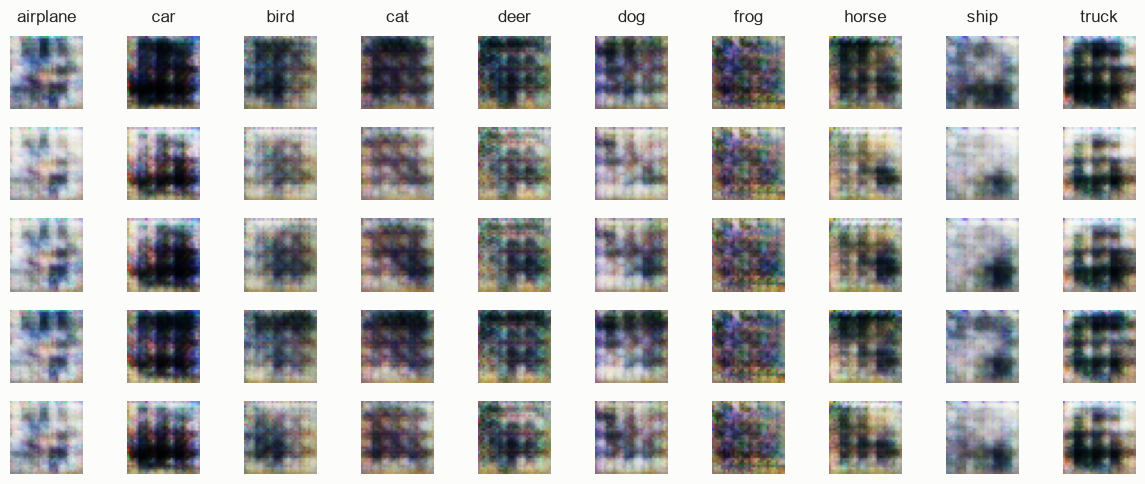

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
experiment_1_ttur,NaN,0.691669,0.691733,0.694661,277.488647


In [ ]:
# Generate a sample of images and log FID score into the results dict. 
from torchmetrics.image.fid import FrechetInceptionDistance

generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_1_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_1_results, "experiment_1_ttur")
results

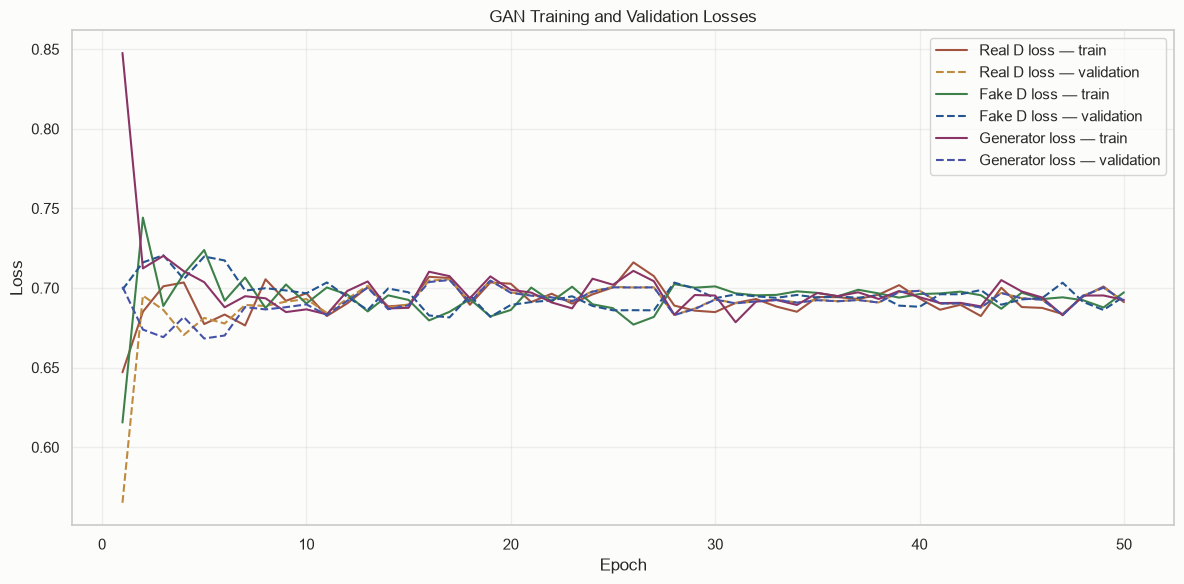

In [26]:
# Plot this experiment's generator/discriminator loss curves against the baseline's, on the same axes.
def plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track):
    plt.figure(figsize=(12, 6))

    tracks = {"Real D loss": real_d_loss_track,"Fake D loss": fake_d_loss_track,"Generator loss": g_loss_track}

    for label, track in tracks.items():
        train_values = track.get("train", [])
        val_values = track.get("val", [])

        if train_values:
            plt.plot(range(1, len(train_values) + 1),train_values,label=f"{label} — train")

        if val_values:
            plt.plot(range(1, len(val_values) + 1),val_values,linestyle="--",label=f"{label} — validation")

    plt.title("GAN Training and Validation Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

TTUR produced more balanced validation losses than the baseline: by the final epoch, the generator, real-discriminator, and fake-discriminator losses had converged to approximately 0.692, 0.692, and 0.695, while both D(x) and D(G(z)) were close to 0.5. In comparison, the baseline ended with a higher generator loss of 0.909 and lower real/fake discriminator losses of 0.546 and 0.552, suggesting that its discriminator was stronger than its generator. However, balanced adversarial losses did not translate into better generated images: TTUR's FID was 277.489, substantially worse than the baseline FID of 121.398. Overall, these results do not support the hypothesis; the near-0.693 losses appear to reflect a stalled equilibrium rather than useful improvement.

## 5. Experiment 2: Label Smoothing

Hypothesis: the baseline's hard 0/1 discriminator targets can make it overconfident and easy to saturate, so one-sided label smoothing (real target 0.9 instead of 1.0) should raise the quality score by keeping discriminator gradients informative for longer — checked against the risk of smoothing too much and weakening the discriminator's signal to the generator.

In [31]:
G = generator(noise_dim).to(device)
D = discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

In [36]:
# Build and train a GAN identical to baseline except the discriminator's real-image target is smoothed from 1.0 to 0.9.
for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_smooth = torch.full((batch_size,), 0.9).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_smooth) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)




Epoch 0

D(x) = 0.5183
D(G(z)) = 0.3894
D Loss (real): 0.866 | D Loss (fake): 0.540
Generator Loss: 1.012
== Validation ==
D(x) = 0.5092
D(G(z)) = 0.4389
D Loss (real): 0.697 | D Loss (fake): 0.587
Generator Loss: 0.837


Epoch 1

D(x) = 0.4734
D(G(z)) = 0.3793
D Loss (real): 0.897 | D Loss (fake): 0.490
Generator Loss: 1.048
== Validation ==
D(x) = 0.5054
D(G(z)) = 0.4050
D Loss (real): 0.697 | D Loss (fake): 0.527
Generator Loss: 0.922


Epoch 2

D(x) = 0.5313
D(G(z)) = 0.2953
D Loss (real): 0.645 | D Loss (fake): 0.472
Generator Loss: 1.379
== Validation ==
D(x) = 0.4806
D(G(z)) = 0.3845
D Loss (real): 0.767 | D Loss (fake): 0.498
Generator Loss: 0.991


Epoch 3

D(x) = 0.5789
D(G(z)) = 0.3072
D Loss (real): 0.640 | D Loss (fake): 0.417
Generator Loss: 1.377
== Validation ==
D(x) = 0.5937
D(G(z)) = 0.3525
D Loss (real): 0.544 | D Loss (fake): 0.448
Generator Loss: 1.096


Epoch 4

D(x) = 0.5551
D(G(z)) = 0.2697
D Loss (real): 0.639 | D Loss (fake): 0.423
Generator Loss: 1.525
== V

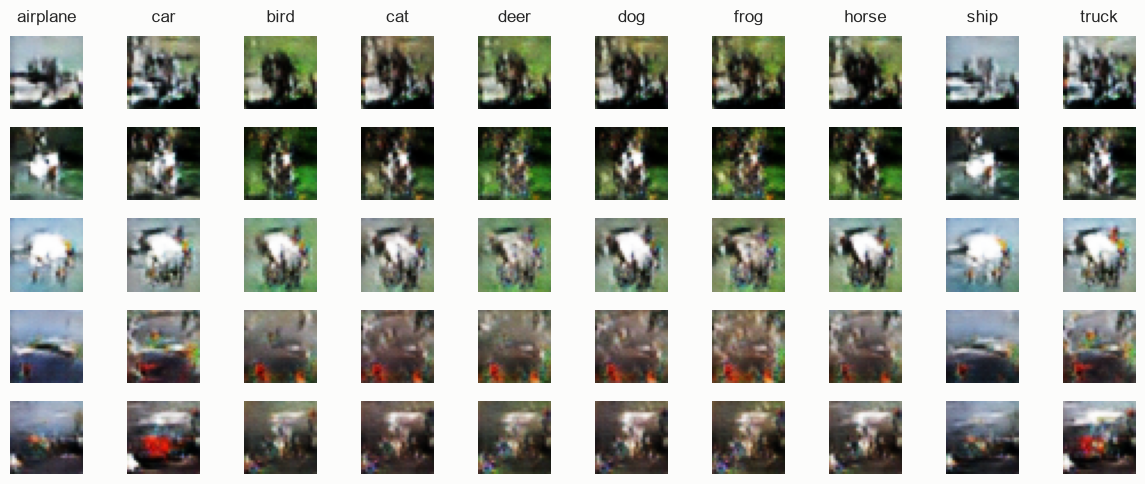

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
experiment_1_ttur,NaN,0.691669,0.691733,0.694661,277.488647
experiment_2_labelsmoothing,NaN,0.974645,0.569433,0.518256,118.233215


In [ ]:
# Generate a sample of images and log FID score into the results dict. 
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_2_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_2_results, "experiment_2_labelsmoothing")
results

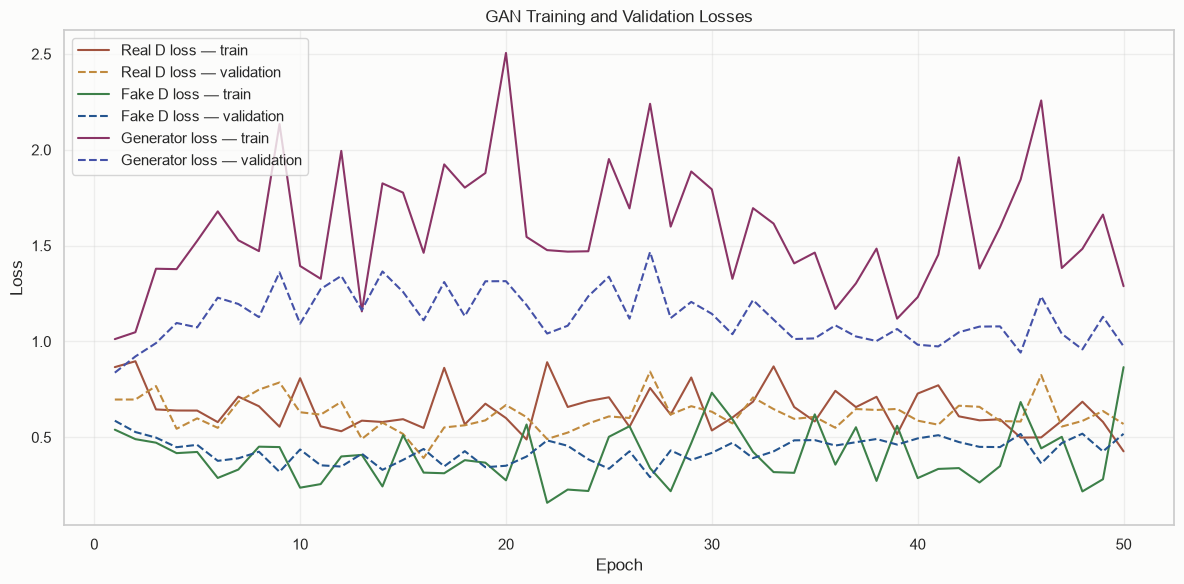

In [ ]:
# Plot this experiment's generator/discriminator loss curves against the baseline's, on the same axes.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Label smoothing produced a small quantitative improvement over the baseline: its FID decreased from `121.398` to `118.233`, an improvement of approximately `2.61%` (lower is better). However, the validation losses were not more balanced or stable than the baseline's. By the final epoch, the generator, real-discriminator, and fake-discriminator losses were approximately `0.975`, `0.569`, and `0.518`, compared with the baseline's `0.909`, `0.546`, and `0.552`. The curves also remained oscillatory across training, with validation generator loss ranging from about `0.837` to `1.467`, while the two discriminator losses stayed lower. Overall, label smoothing slightly improved FID but did not clearly improve the balance of adversarial training, providing only partial support for the hypothesis.

## 6. Experiment 3: Spectral Normalization

Hypothesis: the baseline discriminator's weights are unconstrained and can grow to dominate the generator, so applying spectral normalization to the discriminator's conv layers should raise the quality score by capping its Lipschitz constant and stabilizing training — checked against the risk of over-constraining the discriminator so it can no longer distinguish real from fake effectively.

In [44]:
# Build and train a GAN identical to baseline except the discriminator's conv layers are wrapped with spectral normalization.
from torch.nn.utils.parametrizations import spectral_norm

class spectral_discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = spectral_norm(nn.Conv2d(13, 32, 3, 2, 1)) # 32x32 -> 16x16

        self.conv2 = spectral_norm(nn.Conv2d(32, 64, 3, 2, 1)) # 16x16 -> 8x8

        self.conv3 = spectral_norm(nn.Conv2d(64, 128, 3, 2, 1)) # 8x8 -> 4x4

        self.fc_out = spectral_norm(nn.Linear(128*4*4, 1)) 
        # activations
        
        self.leakyrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()

        # reg
        self.dropout2d = nn.Dropout2d(0.3)
        
    def forward(self, x, label):
        batch_size = x.size(0)
        label = label.reshape(batch_size, 10, 1, 1).expand(batch_size, 10, 32, 32)
        x = torch.concat((x, label), dim=-3)
        x = self.leakyrelu(self.conv1(x))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.conv2(x))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.conv3(x))
        x = self.dropout2d(x)
        x = x.flatten(start_dim=1)
        x = self.sigmoid(self.fc_out(x))
        return x

In [45]:
G = generator(noise_dim).to(device)
D = spectral_discriminator().to(device)

g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

In [46]:
# Build and train a GAN identical to baseline except the discriminator's real-image target is smoothed from 1.0 to 0.9.
for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)




Epoch 0

D(x) = 0.4746
D(G(z)) = 0.4507
D Loss (real): 0.763 | D Loss (fake): 0.608
Generator Loss: 0.806
== Validation ==
D(x) = 0.4676
D(G(z)) = 0.4160
D Loss (real): 0.765 | D Loss (fake): 0.542
Generator Loss: 0.886


Epoch 1

D(x) = 0.5442
D(G(z)) = 0.4417
D Loss (real): 0.689 | D Loss (fake): 0.611
Generator Loss: 0.849
== Validation ==
D(x) = 0.5170
D(G(z)) = 0.4778
D Loss (real): 0.680 | D Loss (fake): 0.657
Generator Loss: 0.748


Epoch 2

D(x) = 0.5209
D(G(z)) = 0.4703
D Loss (real): 0.694 | D Loss (fake): 0.661
Generator Loss: 0.759
== Validation ==
D(x) = 0.4860
D(G(z)) = 0.4558
D Loss (real): 0.723 | D Loss (fake): 0.609
Generator Loss: 0.787


Epoch 3

D(x) = 0.4992
D(G(z)) = 0.4680
D Loss (real): 0.708 | D Loss (fake): 0.678
Generator Loss: 0.763
== Validation ==
D(x) = 0.4973
D(G(z)) = 0.4500
D Loss (real): 0.703 | D Loss (fake): 0.600
Generator Loss: 0.801


Epoch 4

D(x) = 0.5383
D(G(z)) = 0.4872
D Loss (real): 0.620 | D Loss (fake): 0.711
Generator Loss: 0.723
== V

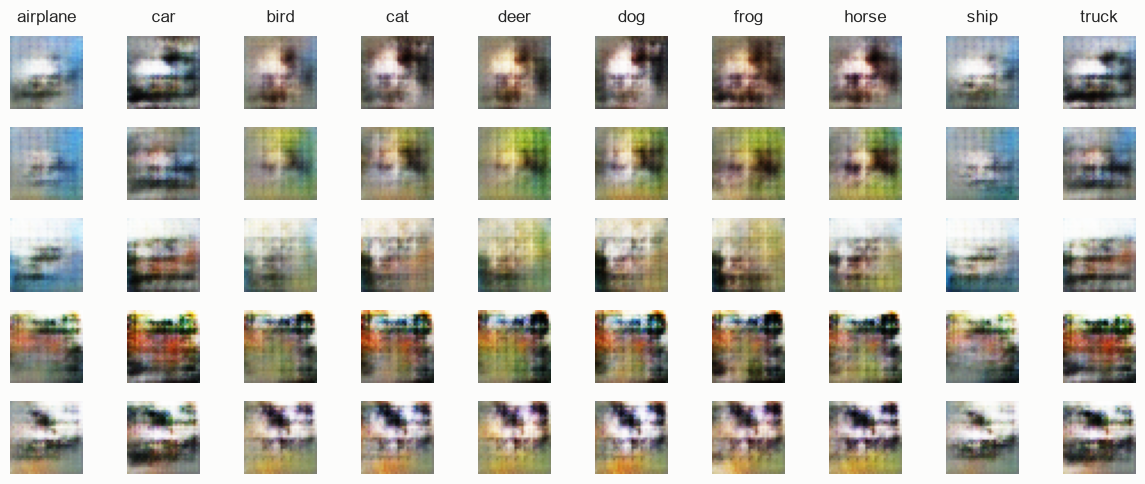

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
experiment_1_ttur,NaN,0.691669,0.691733,0.694661,277.488647
experiment_2_labelsmoothing,NaN,0.974645,0.569433,0.518256,118.233215
experiment_2_spectralnorm,NaN,0.695215,0.695162,0.691113,204.611206


In [ ]:
# Generate a sample of images and log FID score into the results dict. 
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_3_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_3_results, "experiment_3_spectralnorm")
results

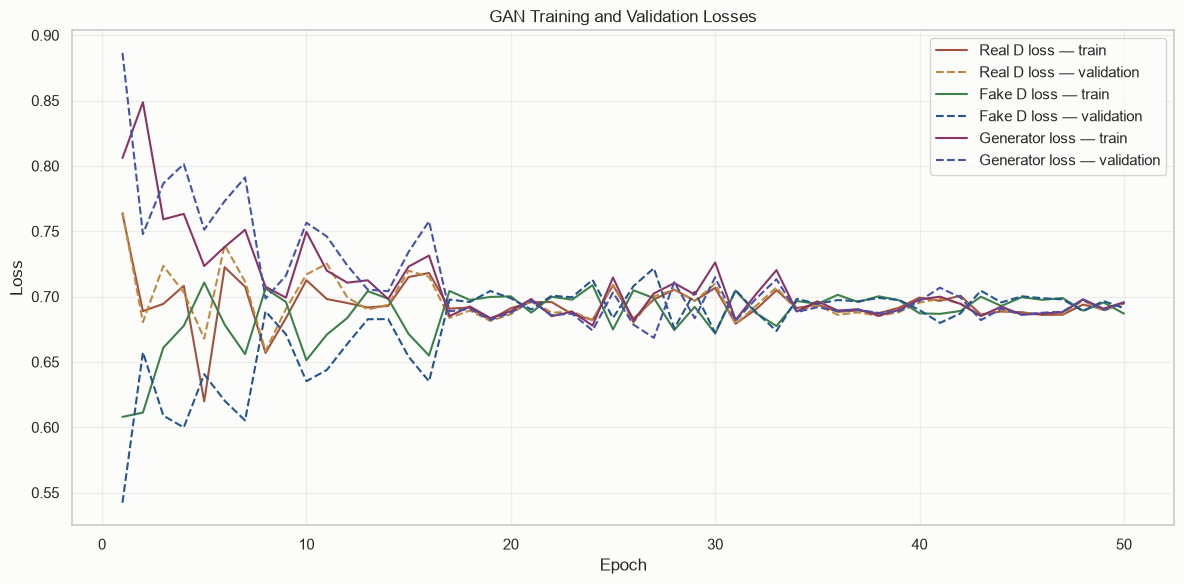

In [48]:
# Plot this experiment's generator/discriminator loss curves against the baseline's, on the same axes.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Spectral normalization did not improve the model: FID increased from `121.398` to `204.611`, making it approximately `68.55%` worse than the baseline. The validation generator, real-discriminator, and fake-discriminator losses converged to approximately `0.695`, `0.695`, and `0.691`, and all six curves clustered near `0.693` after the early epochs. Although this looks numerically stable, it is more consistent with an uninformative equilibrium in which the discriminator remains near random guessing than with productive adversarial training. The hypothesis is therefore not supported; the applied constraint appears to have weakened the discriminator too much.

## 7. Experiment 4: Color vs. Grayscale

Hypothesis (linked to the assignment's discussion question): converting inputs to grayscale removes color as a distinguishing cue, so the quality score should drop for classes that rely heavily on color but may hold up or even simplify shape-dominant classes — this experiment answers the question empirically rather than by reasoning alone.

In [34]:
# Convert the datasets to grayscale and adjust the generator/discriminator channel counts.

def to_grayscale(images):
    from torchvision.transforms.functional import rgb_to_grayscale
    return {"img": rgb_to_grayscale(images)}

grey_train_data = train_data.map(to_grayscale, input_columns=["img"], batched=True, batch_size=500, num_proc=cpu_cores)
grey_val_data = val_data.map(to_grayscale, input_columns=["img"], batched=True, batch_size=500, num_proc=cpu_cores)
grey_test_data = test_data.map(to_grayscale, input_columns=["img"], batched=True, batch_size=500, num_proc=cpu_cores)

G = generator(noise_dim)
D = discriminator()

G.convT3 = nn.ConvTranspose2d(32, 1, 4, 2, 1)
D.conv1 = nn.Conv2d(11, 32, 3, 2, 1)

G = G.to(device)
D = D.to(device)

In [35]:
# Build and train a GAN identical to baseline except for the single-channel input/output.
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}


grey_train_loader = DataLoader(grey_train_data,batch_size=bs,shuffle=True,
                          num_workers=cpu_cores,pin_memory=True,persistent_workers=True,prefetch_factor=2)
grey_val_loader = DataLoader(grey_val_data,batch_size=bs,shuffle=True,drop_last=True,
                        num_workers=cpu_cores,pin_memory=True,persistent_workers=True,prefetch_factor=2)

In [36]:
# Generate a sample of images, score with score_from_labels() (Section 3.1) split by class, and log quality score + loss balance into the results dict.
# Build and train a GAN identical to baseline except the discriminator's real-image target is smoothed from 1.0 to 0.9.
for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(grey_train_loader):
        
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)
        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(grey_val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)




Epoch 0

D(x) = 0.8712
D(G(z)) = 0.0459
D Loss (real): 0.145 | D Loss (fake): 0.103
Generator Loss: 4.323
== Validation ==
D(x) = 0.9142
D(G(z)) = 0.1673
D Loss (real): 0.111 | D Loss (fake): 0.188
Generator Loss: 1.892


Epoch 1

D(x) = 0.5500
D(G(z)) = 0.4898
D Loss (real): 0.733 | D Loss (fake): 0.633
Generator Loss: 0.749
== Validation ==
D(x) = 0.5499
D(G(z)) = 0.4890
D Loss (real): 0.615 | D Loss (fake): 0.688
Generator Loss: 0.734


Epoch 2

D(x) = 0.5999
D(G(z)) = 0.3538
D Loss (real): 0.517 | D Loss (fake): 0.537
Generator Loss: 1.144
== Validation ==
D(x) = 0.5388
D(G(z)) = 0.4093
D Loss (real): 0.648 | D Loss (fake): 0.540
Generator Loss: 0.918


Epoch 3

D(x) = 0.5303
D(G(z)) = 0.3789
D Loss (real): 0.666 | D Loss (fake): 0.741
Generator Loss: 1.165
== Validation ==
D(x) = 0.5893
D(G(z)) = 0.4117
D Loss (real): 0.565 | D Loss (fake): 0.554
Generator Loss: 0.942


Epoch 4

D(x) = 0.6559
D(G(z)) = 0.2831
D Loss (real): 0.413 | D Loss (fake): 0.562
Generator Loss: 1.506
== V

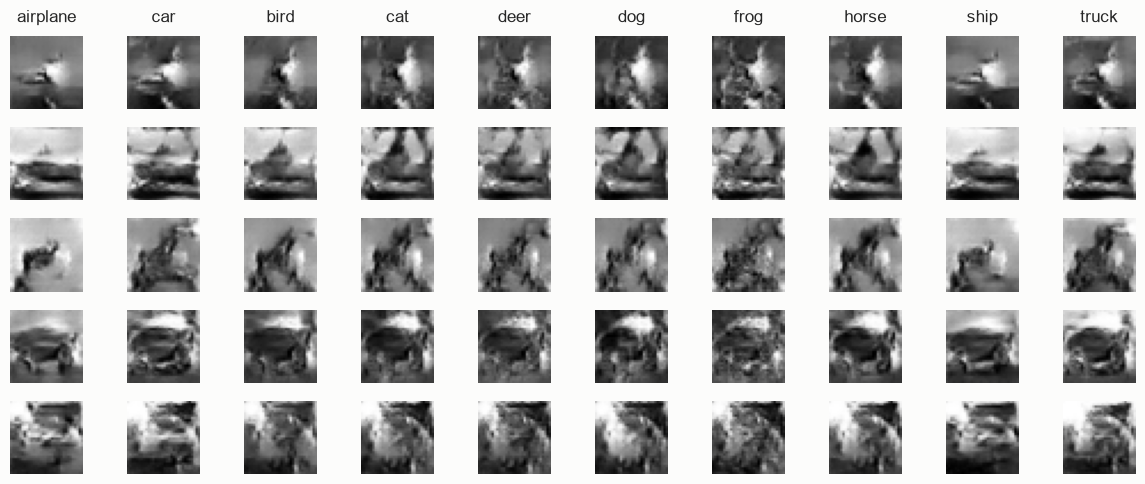

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
experiment_1_ttur,NaN,0.691669,0.691733,0.694661,277.488647
experiment_2_labelsmoothing,NaN,0.974645,0.569433,0.518256,118.233215
experiment_3_spectralnorm,NaN,0.695215,0.695162,0.691113,204.611206
experiment_4_greyscale,NaN,0.742639,0.506967,0.679024,102.814789


In [37]:
# Generate a sample of images and log FID score into the results dict. 
G.eval()
fixed_noise_progression_grid[e + 1] = []

with torch.no_grad():
    fig, ax = plt.subplots(5, 10, figsize=(12, 5))
    for col, a in enumerate(ax[0]):
        a.set_title(f"{classes[col]}", pad=10)

    for idx in range(10):
        one_hot_label = [0] * 10
        one_hot_label[idx] = 1
        one_hot_label = torch.Tensor(one_hot_label).expand(5, -1).to(device)
        noise = val_noise[0:5].to(device)
        per_class_generated_imgs = G(noise, one_hot_label)

        fixed_noise_progression_grid[e + 1].append(
            per_class_generated_imgs[0].detach().cpu().numpy()
        )

        for img in range(per_class_generated_imgs.size(0)):
            ax[img][idx].imshow(F_t.to_pil_image(
                (127.5 * (per_class_generated_imgs[img] + 1)).to(torch.uint8)
            ), cmap='grey')
            ax[img][idx].axis("off")

    plt.tight_layout()
    plt.show()

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in grey_val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        # InceptionV3 expects RGB input, so replicate the grayscale channel.
        real_images_fid = ((real_images + 1) / 2).clamp(0, 1).repeat(1, 3, 1, 1)
        fake_images_fid = ((fake_images + 1) / 2).clamp(0, 1).repeat(1, 3, 1, 1)

        fid.update(real_images_fid, real=True)
        fid.update(fake_images_fid, real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_4_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_4_results, "experiment_4_greyscale")
results

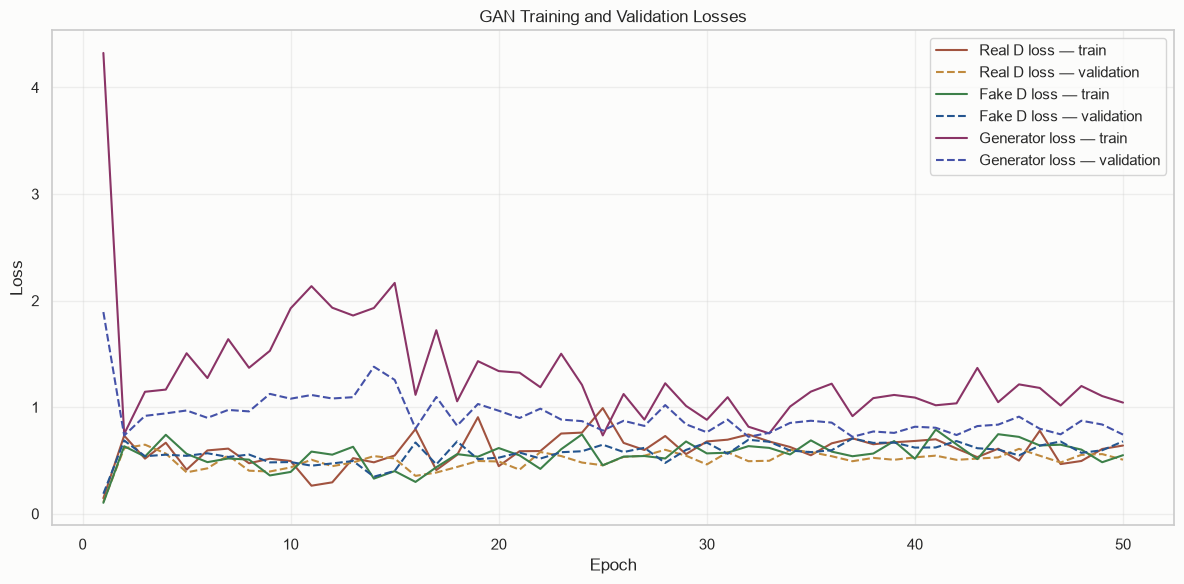

In [39]:
# Plot this experiment's generator/discriminator loss curves against the color baseline's, on the same axes.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Discussion: Color vs. Grayscale, Empirically

Grayscale reduced FID from `121.398` to `102.815`, an improvement of approximately `15.31%`, so the distribution-level result contradicts the prediction that removing color would necessarily make generation harder. The final validation losses were approximately `0.743` for the generator, `0.507` for real discriminator inputs, and `0.679` for fake inputs. The fixed-noise sample grid retained coarse silhouettes but changed little between several class labels, indicating that class specificity was still weak. No per-class manual quality scores were recorded for this experiment, so the available evidence cannot establish which individual classes benefited or deteriorated.

## 8. Experiment 5: Engineered Conditioning Features

Hypothesis: a bare one-hot label only tells the generator/discriminator "which of 10 buckets," so concatenating each class's mean per-channel color statistics (from `vae_eda.ipynb` Section 5, the same shared EDA both architectures use) alongside the one-hot vector should raise the quality score by giving both networks a richer conditioning signal — checked against the risk that the auxiliary features are redundant with one-hot or add noise the discriminator has to learn to ignore.

In [43]:
# Compute each class's mean RGB values and append them to its one-hot label.
class_rgb_sums = torch.zeros(len(classes), 3)
class_counts = torch.zeros(len(classes))

for batch in train_loader:
    images = batch["img"].float()
    class_ids = batch["label"].argmax(dim=1)
    image_rgb_means = images.mean(dim=(2, 3))
    class_rgb_sums.index_add_(0, class_ids, image_rgb_means)
    class_counts.index_add_(0, class_ids, torch.ones_like(class_ids, dtype=torch.float32))

class_rgb_vectors = class_rgb_sums / class_counts.unsqueeze(1)

def attach_rgb_vector(labels):
    labels = torch.as_tensor(labels, dtype=torch.float32)
    class_ids = labels.argmax(dim=1)
    augmented_labels = torch.cat((labels, class_rgb_vectors[class_ids]), dim=1)
    return {"label": augmented_labels.tolist()}

rgb_train_data = train_data.map(attach_rgb_vector, input_columns=["label"], batched=True, batch_size=500).with_format("torch")
rgb_val_data = val_data.map(attach_rgb_vector, input_columns=["label"], batched=True, batch_size=500).with_format("torch")

G = generator(noise_dim)
D = discriminator()

G.proj = nn.Linear(noise_dim + 13, 128 * 4 * 4)
D.conv1 = nn.Conv2d(16, 32, 3, 2, 1)

# Feed the three auxiliary values into D as constant feature maps while preserving its original 10-label forward method.
def prepare_rgb_conditioning(module, inputs):
    images, labels = inputs
    auxiliary_maps = labels[:, 10:].reshape(-1, 3, 1, 1).expand(-1, -1, 32, 32)
    return torch.cat((images, auxiliary_maps), dim=1), labels[:, :10]

D.register_forward_pre_hook(prepare_rgb_conditioning)
G = G.to(device)
D = D.to(device)

rgb_train_loader = DataLoader(rgb_train_data, batch_size=bs, shuffle=True,
                              num_workers=6, pin_memory=True,
                              persistent_workers=True, prefetch_factor=2)
rgb_val_loader = DataLoader(rgb_val_data, batch_size=bs, shuffle=True, drop_last=True,
                            num_workers=6, pin_memory=True,
                            persistent_workers=True, prefetch_factor=2)

class_rgb_vectors_df = pd.DataFrame(
    class_rgb_vectors.numpy(), index=classes, columns=["mean_r", "mean_g", "mean_b"]
)
class_rgb_vectors_df

Map: 100%|██████████| 5000/5000 [00:00<00:00, 41595.14 examples/s]


,mean_r,mean_g,mean_b
airplane,0.053313,0.122054,0.178764
car,-0.057367,-0.090588,-0.105671
bird,-0.020485,-0.015324,-0.149567
cat,-0.006809,-0.085950,-0.168843
deer,-0.056804,-0.069991,-0.243452
dog,0.000925,-0.070781,-0.166345
frog,-0.060396,-0.123451,-0.309782
horse,0.003357,-0.040596,-0.166429
ship,-0.018714,0.051434,0.110057
truck,-0.001329,-0.028078,-0.042958


In [45]:
# Build and train a GAN identical to baseline except the conditioning input is [one-hot label, auxiliary color-stats vector] instead of one-hot alone.
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(rgb_train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(rgb_val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0

D(x) = 0.5734
D(G(z)) = 0.3346
D Loss (real): 0.533 | D Loss (fake): 0.626
Generator Loss: 1.286
== Validation ==
D(x) = 0.6180
D(G(z)) = 0.4875
D Loss (real): 0.518 | D Loss (fake): 0.712
Generator Loss: 0.768


Epoch 1

D(x) = 0.7045
D(G(z)) = 0.3112
D Loss (real): 0.541 | D Loss (fake): 0.474
Generator Loss: 1.527
== Validation ==
D(x) = 0.6584
D(G(z)) = 0.3341
D Loss (real): 0.446 | D Loss (fake): 0.416
Generator Loss: 1.136


Epoch 2

D(x) = 0.7992
D(G(z)) = 0.1766
D Loss (real): 0.242 | D Loss (fake): 0.234
Generator Loss: 2.393
== Validation ==
D(x) = 0.6925
D(G(z)) = 0.1852
D Loss (real): 0.403 | D Loss (fake): 0.214
Generator Loss: 1.864


Epoch 3

D(x) = 0.7911
D(G(z)) = 0.2687
D Loss (real): 0.376 | D Loss (fake): 0.328
Generator Loss: 1.678
== Validation ==
D(x) = 0.6775
D(G(z)) = 0.2099
D Loss (real): 0.435 | D Loss (fake): 0.252
Generator Loss: 1.840


Epoch 4

D(x) = 0.7712
D(G(z)) = 0.1907
D Loss (real): 0.253 | D Loss (fake): 0.216
Generator Loss: 2.292
== V

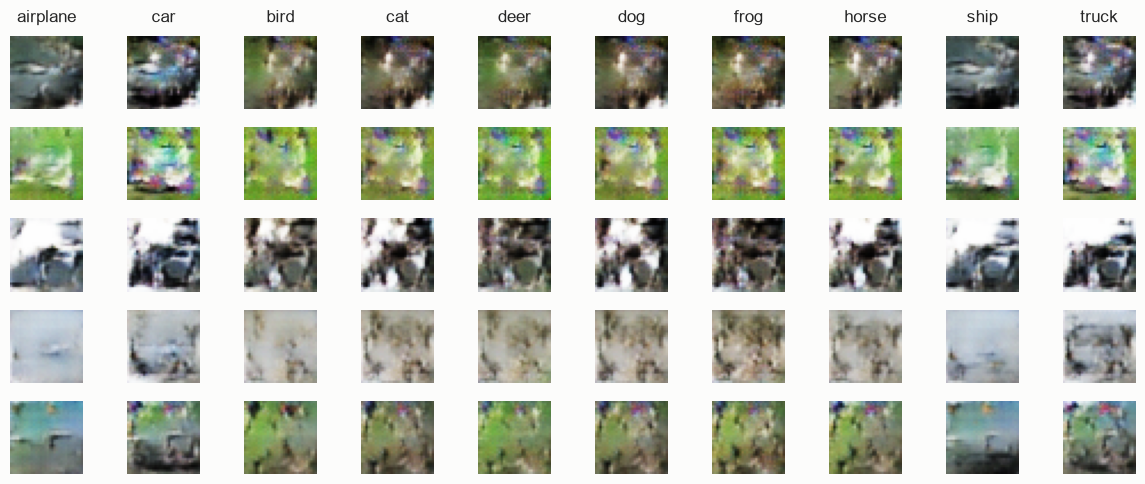

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
experiment_1_ttur,NaN,0.691669,0.691733,0.694661,277.488647
experiment_2_labelsmoothing,NaN,0.974645,0.569433,0.518256,118.233215
experiment_3_spectralnorm,NaN,0.695215,0.695162,0.691113,204.611206
experiment_4_greyscale,NaN,0.742639,0.506967,0.679024,102.814789
experiment_5_engineered_conditioning,NaN,0.854043,0.573656,0.595989,119.930573


In [46]:
# Generate a sample of images, and log FID + other metrics into the results dict.
def generate_rgb_conditioned_class_images(G, n, e):
    G.eval()
    fixed_noise_progression_grid[e + 1] = []

    with torch.no_grad():
        fig, ax = plt.subplots(n, 10, figsize=(12, 5))
        for col, a in enumerate(ax[0]):
            a.set_title(f"{classes[col]}", pad=10)

        for idx in range(10):
            one_hot_label = [0] * 10
            one_hot_label[idx] = 1
            conditioned_label = torch.cat((
                torch.tensor(one_hot_label, dtype=torch.float32),
                class_rgb_vectors[idx],
            )).expand(n, -1).to(device)
            noise = val_noise[0:n].to(device)
            per_class_generated_imgs = G(noise, conditioned_label)

            fixed_noise_progression_grid[e + 1].append(
                per_class_generated_imgs[0].detach().cpu().numpy()
            )

            for img in range(per_class_generated_imgs.size(0)):
                ax[img][idx].imshow(F_t.to_pil_image(
                    (127.5 * (per_class_generated_imgs[img] + 1)).to(torch.uint8)
                ))
                ax[img][idx].axis("off")

        plt.tight_layout()
        plt.show()

generate_rgb_conditioned_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in rgb_val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_5_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_5_results, "experiment_5_engineered_conditioning")
results

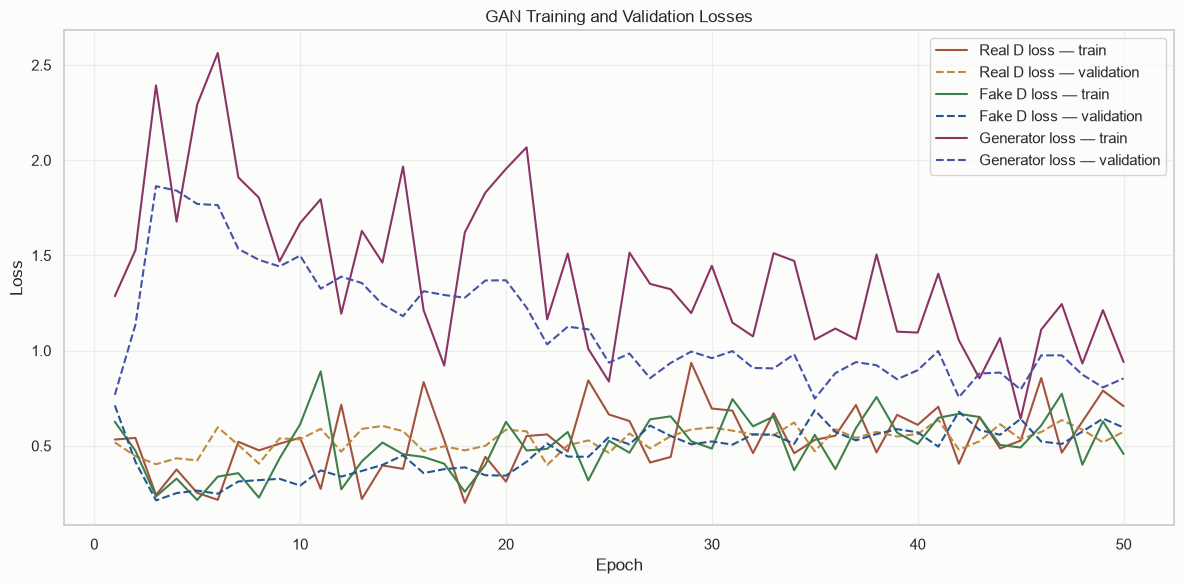

In [47]:
# Plot this experiment's generator/discriminator loss curves 
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Engineered RGB conditioning produced a modest improvement: FID decreased from `121.398` to `119.931`, or approximately `1.21%`. Its final validation losses were approximately `0.854` for the generator, `0.574` for real discriminator inputs, and `0.596` for fake inputs. The validation generator loss generally declined after its early peak, but the training curves remained visibly oscillatory, so the additional features did not make optimization consistently smoother. The result provides limited support for richer conditioning, although the small FID change suggests that the class-mean RGB values add little information beyond the one-hot labels.

## 9. Experiment 6: Data Augmentation

Hypothesis: augmentation (e.g. random horizontal flip) exposes the discriminator to more visual variation per class without new data, which should raise the quality score by making the discriminator generalize instead of memorizing exact training images (a stronger discriminator gives the generator a better training signal) — checked against the risk that some flips are semantically wrong for a class and could confuse conditioning rather than help it.

In [48]:
# Define an augmentation pipeline (e.g. random horizontal flip) applied to the training set only.
augmentation_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=5,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05),
        )
    ], p=0.4),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.5),
        )
    ], p=0.15),
])

In [49]:
# Build and train a GAN identical to baseline except the discriminator's real-image inputs are passed through the augmentation pipeline.
G = generator(noise_dim).to(device)
D = discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = augmentation_pipeline(sample['img'].to(device, non_blocking=True))
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0

D(x) = 0.7843
D(G(z)) = 0.1142
D Loss (real): 0.408 | D Loss (fake): 0.360
Generator Loss: 3.167
== Validation ==
D(x) = 0.8473
D(G(z)) = 0.2662
D Loss (real): 0.211 | D Loss (fake): 0.355
Generator Loss: 1.577


Epoch 1

D(x) = 0.6870
D(G(z)) = 0.2192
D Loss (real): 0.365 | D Loss (fake): 0.344
Generator Loss: 1.765
== Validation ==
D(x) = 0.6021
D(G(z)) = 0.3232
D Loss (real): 0.566 | D Loss (fake): 0.401
Generator Loss: 1.178


Epoch 2

D(x) = 0.5960
D(G(z)) = 0.3427
D Loss (real): 0.673 | D Loss (fake): 0.627
Generator Loss: 1.195
== Validation ==
D(x) = 0.5509
D(G(z)) = 0.4392
D Loss (real): 0.609 | D Loss (fake): 0.589
Generator Loss: 0.840


Epoch 3

D(x) = 0.5820
D(G(z)) = 0.3126
D Loss (real): 0.557 | D Loss (fake): 0.649
Generator Loss: 1.302
== Validation ==
D(x) = 0.5703
D(G(z)) = 0.4397
D Loss (real): 0.581 | D Loss (fake): 0.589
Generator Loss: 0.840


Epoch 4

D(x) = 0.6984
D(G(z)) = 0.1699
D Loss (real): 0.314 | D Loss (fake): 0.503
Generator Loss: 2.197
== V

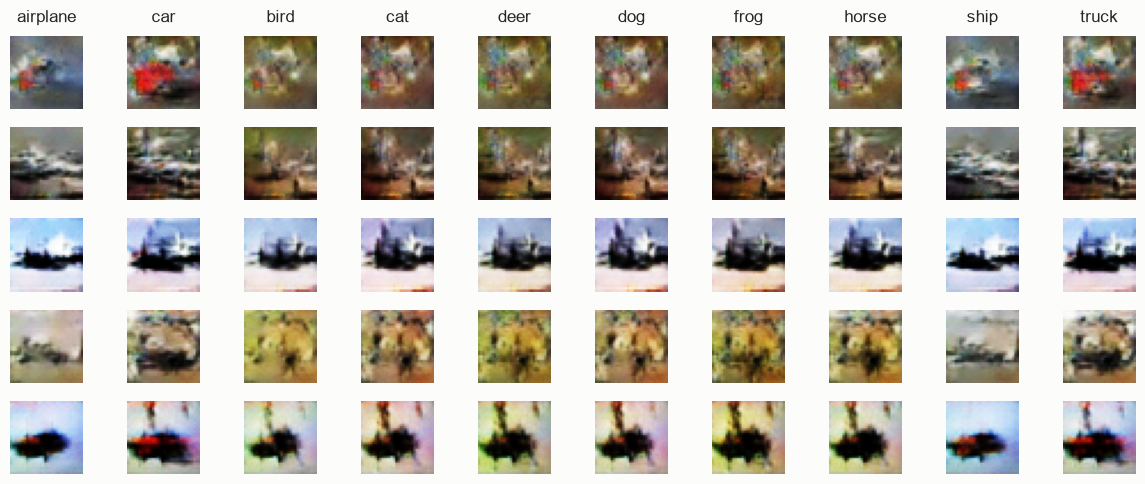

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
experiment_1_ttur,NaN,0.691669,0.691733,0.694661,277.488647
experiment_2_labelsmoothing,NaN,0.974645,0.569433,0.518256,118.233215
experiment_3_spectralnorm,NaN,0.695215,0.695162,0.691113,204.611206
experiment_4_greyscale,NaN,0.742639,0.506967,0.679024,102.814789
experiment_5_engineered_conditioning,NaN,0.854043,0.573656,0.595989,119.930573
experiment_6_augmentation,NaN,1.065786,0.637636,0.468831,117.394493


In [50]:
# Generate a sample of images, and log FID + other metrics into the results dict.
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_6_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_6_results, "experiment_6_augmentation")
results

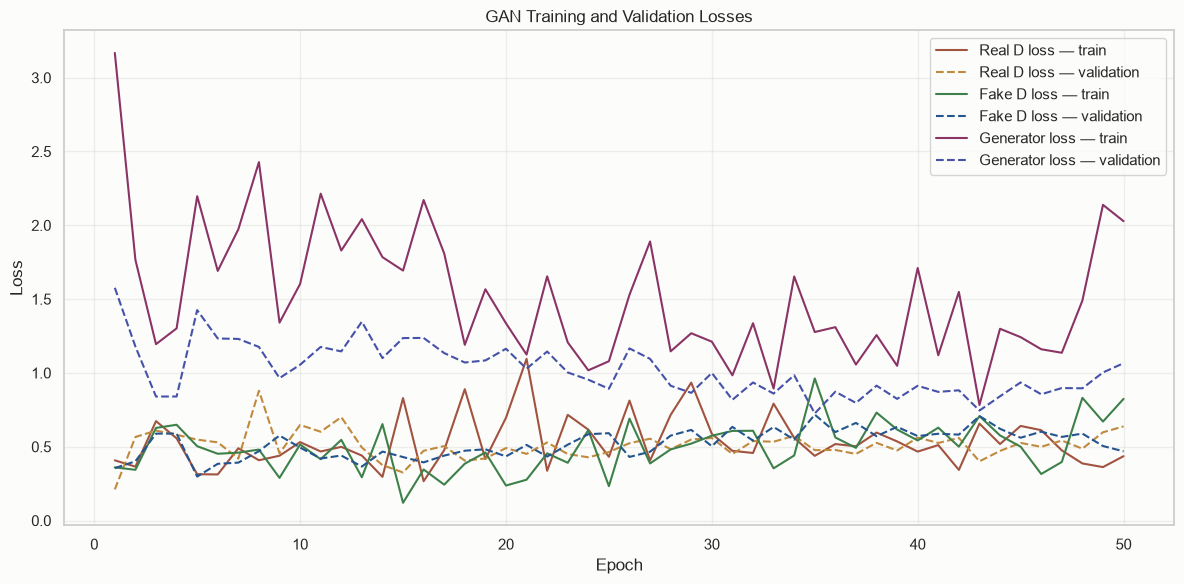

In [51]:
# Plot this experiment's generator/discriminator loss curves 
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Soft augmentation achieved the best non-grayscale FID among the compatible single changes, reducing it from `121.398` to `117.394`, an improvement of approximately `3.30%`. The final validation generator, real-discriminator, and fake-discriminator losses were approximately `1.066`, `0.638`, and `0.469`. However, the curves remained oscillatory and the generator loss stayed above both discriminator components, so there is no clear evidence that augmentation made the training signal more balanced or stable. The lower FID nevertheless supports the hypothesis that mild variation in the discriminator's real inputs improved generalization.

## 10. Experiment 7: Auxiliary Classifier GAN (AC-GAN)

Hypothesis: requiring the discriminator to predict both source authenticity and the semantic class of real and generated images should give the generator a stronger class-specific training signal, improving visible separation between classes and raising the quality score - checked against the risk that the auxiliary classification objective dominates adversarial learning.

In [70]:
# Create an AC-GAN discriminator with shared image features, a real/fake head, and a class head.
class acgan_discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
        )
        self.real_fake_out = nn.Linear(128*4*4, 1)
        self.class_out = nn.Linear(128*4*4, len(classes))
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        features = self.features(x)
        features = features.flatten(start_dim=1)
        real_fake_pred = self.sigmoid(self.real_fake_out(features))
        class_logits = self.class_out(features)
        return real_fake_pred, class_logits

In [73]:
# Train on the base train_loader and validate with val_loader using the baseline optimizer settings.
G = generator(noise_dim).to(device)
D = acgan_discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
class_criterion = nn.CrossEntropyLoss()
lambda_class = 1.0
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)
        class_targets = label.argmax(dim=1)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred, real_class_pred = D(img)
        real_source_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1
        real_class_loss = class_criterion(real_class_pred, class_targets)
        real_d_loss = real_source_loss + lambda_class * real_class_loss

        fake_d_pred, fake_class_pred = D(generated_img.detach())
        fake_source_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0
        fake_class_loss = class_criterion(fake_class_pred, class_targets)
        fake_d_loss = fake_source_loss + lambda_class * fake_class_loss

        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred, g_class_pred = D(generated_img) # uses the new discriminator
        g_adversarial_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_class_loss = class_criterion(g_class_pred, class_targets)
        g_loss = g_adversarial_loss + lambda_class * g_class_loss
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred, _ = D(img)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    print(f"Class loss (real/fake): {real_class_loss:.3f} / {fake_class_loss:.3f}")
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)
        class_targets = label.argmax(dim=1)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred, v_real_class_pred = D(img)
                        
            v_fake_pred, v_fake_class_pred = D(v_generated_img)

            v_real_class_loss = class_criterion(v_real_class_pred, class_targets)
            v_fake_class_loss = class_criterion(v_fake_class_pred, class_targets)
            v_real_d_loss = criterion(v_real_pred, target_ones) + lambda_class * v_real_class_loss
            v_fake_d_loss = criterion(v_fake_pred, target_zeros) + lambda_class * v_fake_class_loss
            v_g_loss = criterion(v_fake_pred, target_ones) + lambda_class * v_fake_class_loss

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0

D(x) = 0.9391
D(G(z)) = 0.0481
D Loss (real): 1.891 | D Loss (fake): 2.423
Generator Loss: 6.550
Class loss (real/fake): 1.822 / 2.340
== Validation ==
D(x) = 0.9415
D(G(z)) = 0.3649
D Loss (real): 1.877 | D Loss (fake): 2.711
Generator Loss: 3.271


Epoch 1

D(x) = 0.8049
D(G(z)) = 0.1589
D Loss (real): 2.168 | D Loss (fake): 1.847
Generator Loss: 4.188
Class loss (real/fake): 1.742 / 1.392
== Validation ==
D(x) = 0.7739
D(G(z)) = 0.6267
D Loss (real): 2.155 | D Loss (fake): 2.533
Generator Loss: 1.940


Epoch 2

D(x) = 0.5898
D(G(z)) = 0.3176
D Loss (real): 2.584 | D Loss (fake): 0.832
Generator Loss: 1.725
Class loss (real/fake): 1.817 / 0.247
== Validation ==
D(x) = 0.6318
D(G(z)) = 0.3991
D Loss (real): 2.078 | D Loss (fake): 0.743
Generator Loss: 1.180


Epoch 3

D(x) = 0.7018
D(G(z)) = 0.1945
D Loss (real): 2.036 | D Loss (fake): 0.595
Generator Loss: 2.357
Class loss (real/fake): 1.660 / 0.180
== Validation ==
D(x) = 0.7590
D(G(z)) = 0.2114
D Loss (real): 1.711 | D L

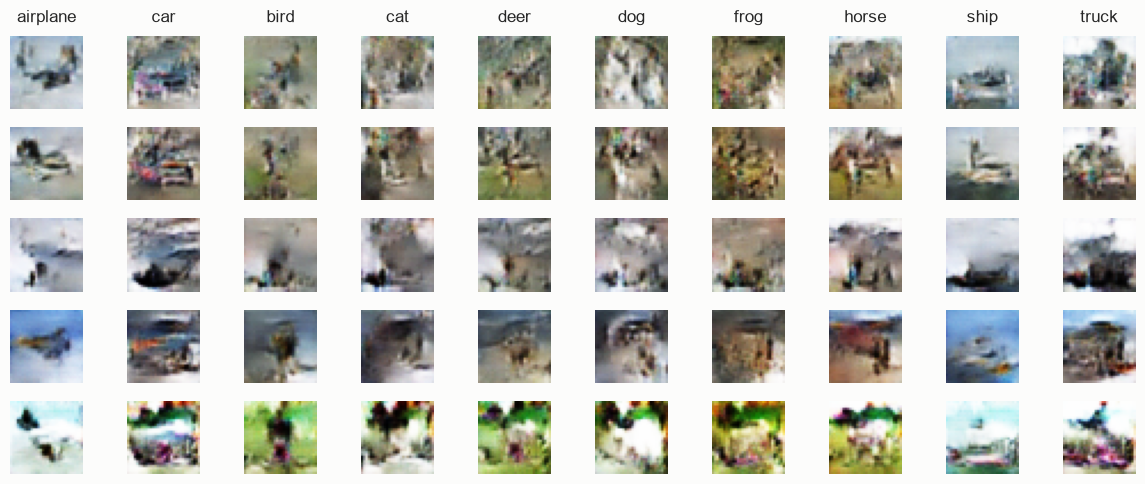

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
experiment_1_ttur,NaN,0.691669,0.691733,0.694661,277.488647
experiment_2_labelsmoothing,NaN,0.974645,0.569433,0.518256,118.233215
experiment_3_spectralnorm,NaN,0.695215,0.695162,0.691113,204.611206
experiment_4_greyscale,NaN,0.742639,0.506967,0.679024,102.814789
experiment_5_engineered_conditioning,NaN,0.854043,0.573656,0.595989,119.930573
experiment_6_augmentation,NaN,1.065786,0.637636,0.468831,117.394493
experiment_7_acgan,NaN,0.895540,1.653923,0.561815,120.611053


In [77]:
# Calculate FID, add the experiment to the results dataframe, and generate five samples per class.
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_7_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_7_results, "experiment_7_acgan")
results

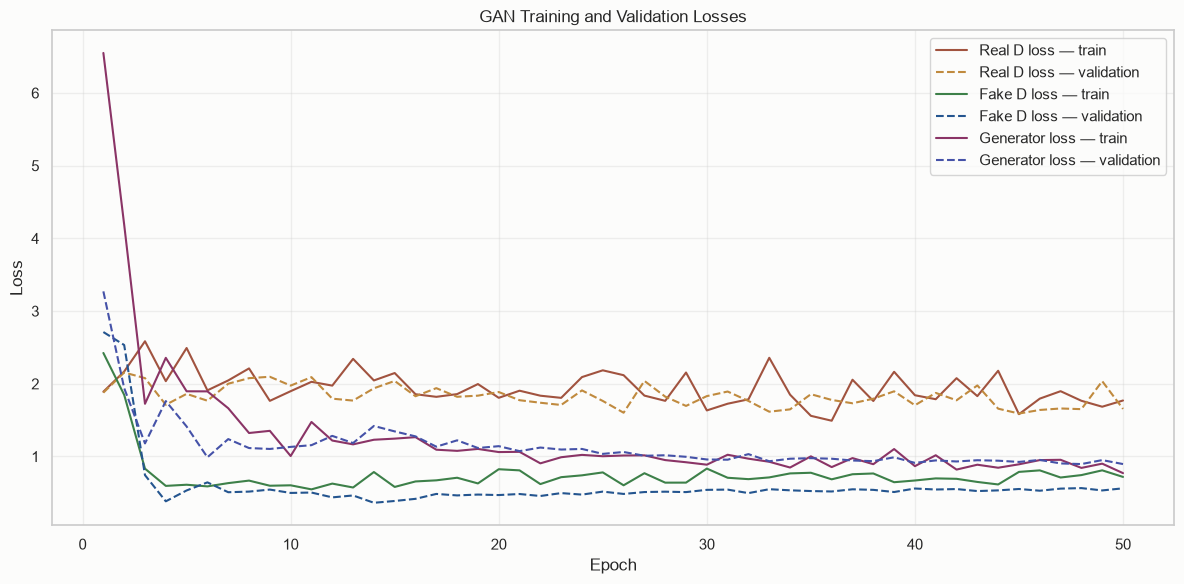

In [78]:
# Plot losses.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

AC-GAN produced a small FID improvement from `121.398` to `120.611`, or approximately `0.65%`. The fixed-noise grid shows more visible label-dependent changes in color and background between vehicle, ship, and animal classes, providing some qualitative support for the auxiliary classification objective. The loss curves settled after the first several epochs, ending at approximately `0.896` for the generator, `1.654` for the real discriminator branch, and `0.562` for the fake branch; the larger real loss is not directly comparable with the other experiments because it includes the auxiliary cross-entropy term. Overall, the stronger semantic objective improved class cues only modestly and did not produce a substantial FID gain.

### 11. Experiment 8: Deeper Architecture

Hypothesis: adding same-resolution convolutional refinement layers between the existing upsampling and downsampling stages should give both networks more capacity to learn useful local features and improve FID, while retaining the DCGAN spatial pathway and shallow fully connected structure. The main risk is that the extra depth makes the adversarial optimization less stable without adding useful class-specific information.

In [79]:
# Define deeper generator and discriminator classes without adding extra fully connected layers.
class deeper_generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 128*4*4)
        self.bn_proj = nn.BatchNorm1d(128*4*4)

        # Keep 4x4, then upsample to 8x8.
        self.convT_same1 = nn.ConvTranspose2d(128, 128, 3, 1, 1)
        self.bn_same1 = nn.BatchNorm2d(128)
        self.convT_up1 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.bn_up1 = nn.BatchNorm2d(64)

        # Keep 8x8, then upsample to 16x16.
        self.convT_same2 = nn.ConvTranspose2d(64, 64, 3, 1, 1)
        self.bn_same2 = nn.BatchNorm2d(64)
        self.convT_up2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.bn_up2 = nn.BatchNorm2d(32)

        # Keep 16x16, then upsample to the 32x32 RGB output.
        self.convT_same3 = nn.ConvTranspose2d(32, 32, 3, 1, 1)
        self.bn_same3 = nn.BatchNorm2d(32)
        self.convT_out = nn.ConvTranspose2d(32, 3, 4, 2, 1)

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=-1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 128, 4, 4)

        x = self.relu(self.bn_same1(self.convT_same1(x)))
        x = self.relu(self.bn_up1(self.convT_up1(x)))
        x = self.relu(self.bn_same2(self.convT_same2(x)))
        x = self.relu(self.bn_up2(self.convT_up2(x)))
        x = self.relu(self.bn_same3(self.convT_same3(x)))
        return self.tanh(self.convT_out(x))


class deeper_discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Downsample 32x32 -> 16x16, then keep 16x16.
        self.conv_down1 = nn.Conv2d(13, 32, 3, 2, 1)
        self.conv_same1 = nn.Conv2d(32, 32, 3, 1, 1)
        self.bn_same1 = nn.BatchNorm2d(32)

        # Downsample 16x16 -> 8x8, then keep 8x8.
        self.conv_down2 = nn.Conv2d(32, 64, 3, 2, 1)
        self.bn_down2 = nn.BatchNorm2d(64)
        self.conv_same2 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn_same2 = nn.BatchNorm2d(64)

        # Downsample 8x8 -> 4x4, then keep the final 4x4 map.
        self.conv_down3 = nn.Conv2d(64, 128, 3, 2, 1)
        self.bn_down3 = nn.BatchNorm2d(128)
        self.conv_same3 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn_same3 = nn.BatchNorm2d(128)

        self.fc_out = nn.Linear(128*4*4, 1)
        self.leakyrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()
        self.dropout2d = nn.Dropout2d(0.3)

    def forward(self, x, label):
        batch_size = x.size(0)
        label = label.reshape(batch_size, 10, 1, 1).expand(batch_size, 10, 32, 32)
        x = torch.concat((x, label), dim=-3)

        x = self.leakyrelu(self.conv_down1(x))
        x = self.leakyrelu(self.bn_same1(self.conv_same1(x)))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn_down2(self.conv_down2(x)))
        x = self.leakyrelu(self.bn_same2(self.conv_same2(x)))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn_down3(self.conv_down3(x)))
        x = self.leakyrelu(self.bn_same3(self.conv_same3(x)))
        x = self.dropout2d(x)

        x = x.flatten(start_dim=1)
        return self.sigmoid(self.fc_out(x))

In [88]:
# Train the deeper GAN with the same loaders, losses, and optimizer settings as the baseline.
G = deeper_generator(noise_dim).to(device)
D = deeper_discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50 

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0

D(x) = 0.7508
D(G(z)) = 0.2026
D Loss (real): 0.272 | D Loss (fake): 0.382
Generator Loss: 1.986
== Validation ==
D(x) = 0.6529
D(G(z)) = 0.4761
D Loss (real): 0.513 | D Loss (fake): 0.690
Generator Loss: 0.783


Epoch 1

D(x) = 0.4942
D(G(z)) = 0.0121
D Loss (real): 0.482 | D Loss (fake): 0.672
Generator Loss: 4.864
== Validation ==
D(x) = 0.4370
D(G(z)) = 0.3546
D Loss (real): 1.065 | D Loss (fake): 0.459
Generator Loss: 1.091


Epoch 2

D(x) = 0.8316
D(G(z)) = 0.0755
D Loss (real): 0.132 | D Loss (fake): 0.227
Generator Loss: 3.085
== Validation ==
D(x) = 0.6642
D(G(z)) = 0.2090
D Loss (real): 0.460 | D Loss (fake): 0.243
Generator Loss: 1.694


Epoch 3

D(x) = 0.7736
D(G(z)) = 0.1540
D Loss (real): 0.901 | D Loss (fake): 0.071
Generator Loss: 2.079
== Validation ==
D(x) = 0.4890
D(G(z)) = 0.3534
D Loss (real): 0.788 | D Loss (fake): 0.454
Generator Loss: 1.104


Epoch 4

D(x) = 0.5698
D(G(z)) = 0.2824
D Loss (real): 0.473 | D Loss (fake): 0.138
Generator Loss: 1.393
== V

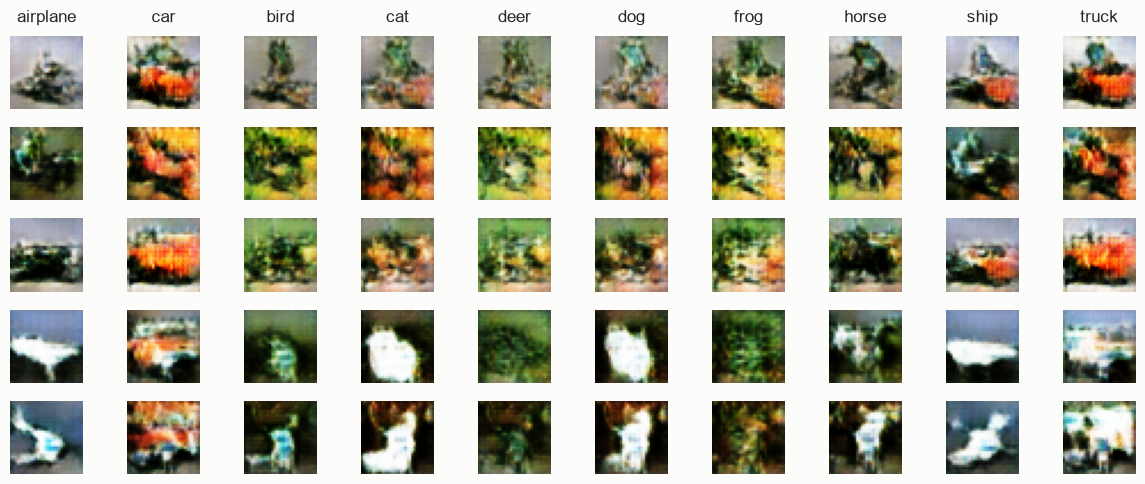

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
experiment_1_ttur,NaN,0.691669,0.691733,0.694661,277.488647
experiment_2_labelsmoothing,NaN,0.974645,0.569433,0.518256,118.233215
experiment_3_spectralnorm,NaN,0.695215,0.695162,0.691113,204.611206
experiment_4_greyscale,NaN,0.742639,0.506967,0.679024,102.814789
experiment_5_engineered_conditioning,NaN,0.854043,0.573656,0.595989,119.930573
experiment_6_augmentation,NaN,1.065786,0.637636,0.468831,117.394493
experiment_7_acgan,NaN,0.895540,1.653923,0.561815,120.611053
experiment_8_deeper_architecture,NaN,0.863213,0.568792,0.643779,142.071945


In [90]:
# Generate five samples per class, calculate FID, and add the experiment metrics to the results dataframe.
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_8_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_8_results, "experiment_8_deeper_architecture")
results

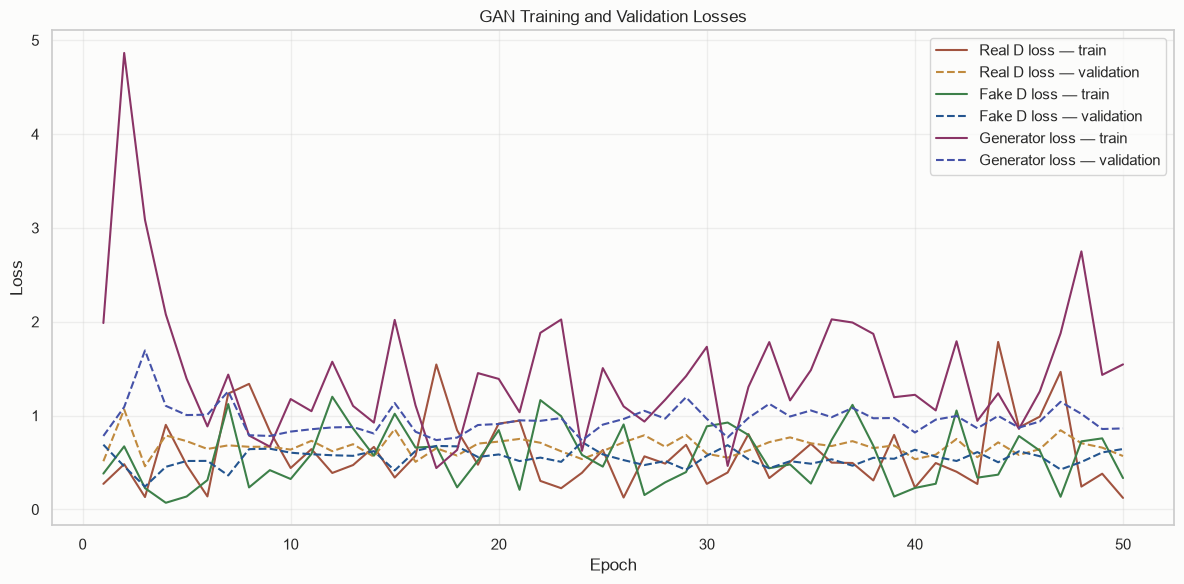

In [91]:
# Plot losses.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

The deeper architecture worsened FID from `121.398` to `142.072`, an increase of approximately `17.03%`. Its final validation losses were approximately `0.863` for the generator, `0.569` for real discriminator inputs, and `0.644` for fake inputs, but the curves contained repeated spikes rather than showing a clear stability benefit. The generated grid retained broad class-associated colors while remaining blurred and inconsistent. The added refinement layers therefore increased optimization difficulty without improving the generated distribution, so the hypothesis is not supported.

### 11.5 Experiment 9: alternating downsample and upsample layers

Hypothesis: replacing the deeper generator's same-resolution transposed convolutions with standard convolutions while retaining transposed convolutions for upsampling may refine local features and reduce transposed-convolution artefacts, potentially improving FID without changing its spatial pathway.

In [93]:
# Copy the deeper generator but use standard convolutions for its same-resolution feature refinement layers.
class alternating_generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 128*4*4)
        self.bn_proj = nn.BatchNorm1d(128*4*4)

        # Keep 4x4 with a standard convolution, then upsample to 8x8.
        self.conv_same1 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn_same1 = nn.BatchNorm2d(128)
        self.convT_up1 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.bn_up1 = nn.BatchNorm2d(64)

        # Keep 8x8 with a standard convolution, then upsample to 16x16.
        self.conv_same2 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn_same2 = nn.BatchNorm2d(64)
        self.convT_up2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.bn_up2 = nn.BatchNorm2d(32)

        # Keep 16x16 with a standard convolution, then produce the 32x32 RGB output.
        self.conv_same3 = nn.Conv2d(32, 32, 3, 1, 1)
        self.bn_same3 = nn.BatchNorm2d(32)
        self.convT_out = nn.ConvTranspose2d(32, 3, 4, 2, 1)

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=-1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 128, 4, 4)

        x = self.relu(self.bn_same1(self.conv_same1(x)))
        x = self.relu(self.bn_up1(self.convT_up1(x)))
        x = self.relu(self.bn_same2(self.conv_same2(x)))
        x = self.relu(self.bn_up2(self.convT_up2(x)))
        x = self.relu(self.bn_same3(self.conv_same3(x)))
        return self.tanh(self.convT_out(x))

In [94]:
# Train with the same discriminator, loaders, losses, and optimizer settings as Experiment 8.
G = alternating_generator(noise_dim).to(device)
D = deeper_discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0

D(x) = 0.9902
D(G(z)) = 0.0021
D Loss (real): 0.007 | D Loss (fake): 0.014
Generator Loss: 7.009
== Validation ==
D(x) = 0.8287
D(G(z)) = 0.1958
D Loss (real): 0.226 | D Loss (fake): 0.221
Generator Loss: 1.683


Epoch 1

D(x) = 0.9891
D(G(z)) = 0.0902
D Loss (real): 0.435 | D Loss (fake): 0.011
Generator Loss: 2.919
== Validation ==
D(x) = 0.6897
D(G(z)) = 0.5481
D Loss (real): 0.410 | D Loss (fake): 0.832
Generator Loss: 0.634


Epoch 2

D(x) = 0.6495
D(G(z)) = 0.3484
D Loss (real): 1.377 | D Loss (fake): 0.206
Generator Loss: 1.227
== Validation ==
D(x) = 0.5884
D(G(z)) = 0.3225
D Loss (real): 0.568 | D Loss (fake): 0.405
Generator Loss: 1.199


Epoch 3

D(x) = 0.8198
D(G(z)) = 0.2345
D Loss (real): 1.260 | D Loss (fake): 0.400
Generator Loss: 1.653
== Validation ==
D(x) = 0.6167
D(G(z)) = 0.3611
D Loss (real): 0.533 | D Loss (fake): 0.462
Generator Loss: 1.063


Epoch 4

D(x) = 0.8521
D(G(z)) = 0.1965
D Loss (real): 0.377 | D Loss (fake): 0.146
Generator Loss: 1.824
== V

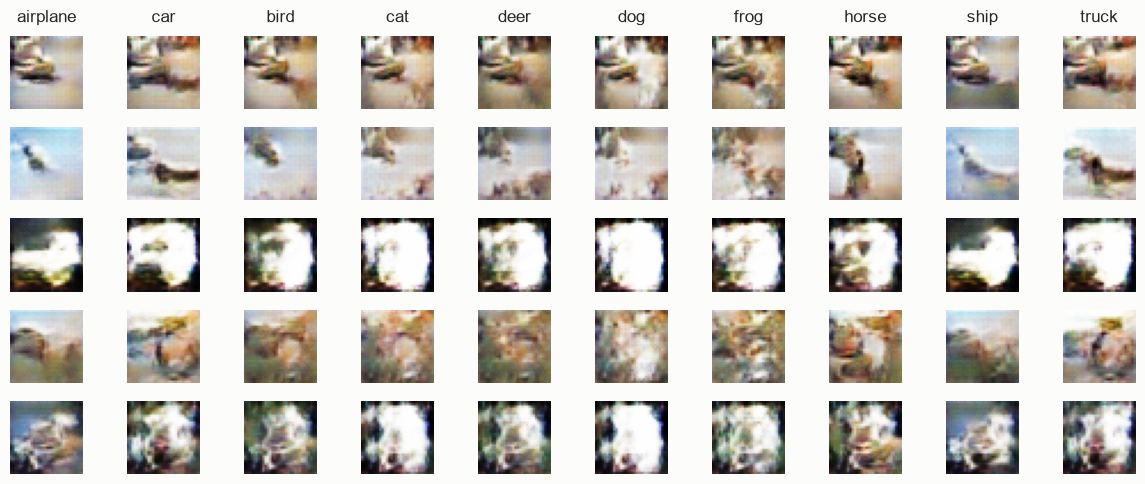

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
experiment_1_ttur,NaN,0.691669,0.691733,0.694661,277.488647
experiment_2_labelsmoothing,NaN,0.974645,0.569433,0.518256,118.233215
experiment_3_spectralnorm,NaN,0.695215,0.695162,0.691113,204.611206
experiment_4_greyscale,NaN,0.742639,0.506967,0.679024,102.814789
experiment_5_engineered_conditioning,NaN,0.854043,0.573656,0.595989,119.930573
experiment_6_augmentation,NaN,1.065786,0.637636,0.468831,117.394493
experiment_7_acgan,NaN,0.895540,1.653923,0.561815,120.611053
experiment_8_deeper_architecture,NaN,0.863213,0.568792,0.643779,142.071945
experiment_9_alternating_downsample_and_upsample_layers,NaN,1.072897,0.617562,0.485366,157.717896


In [95]:
# Generate five samples per class, calculate FID, and add the experiment metrics to the results dataframe.
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_9_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_9_results, "experiment_9_alternating_downsample_and_upsample_layers")
results

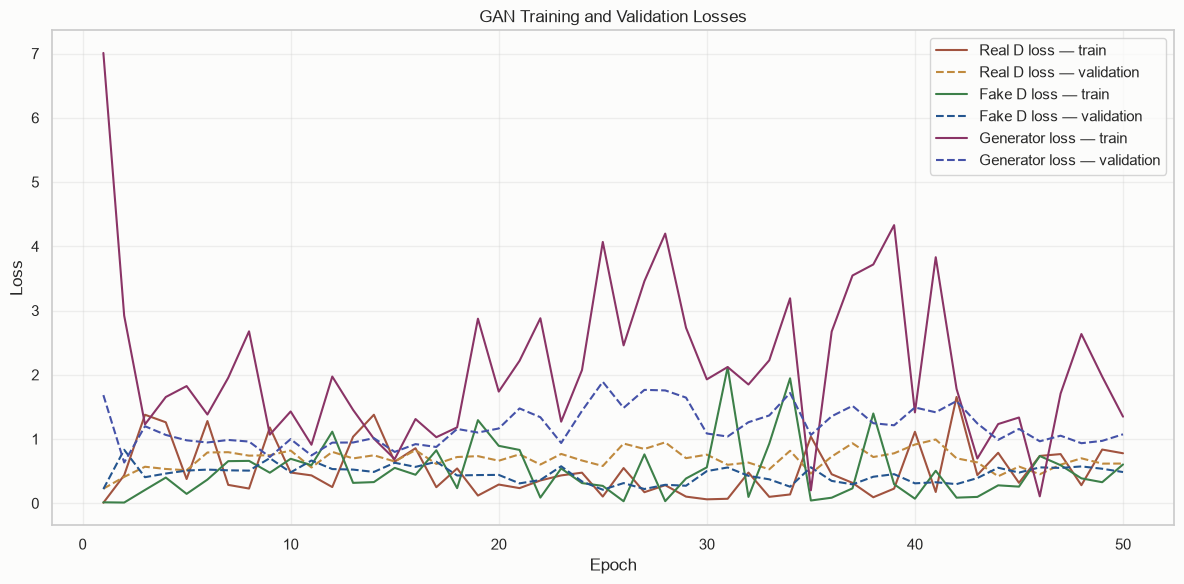

In [96]:
# Plot losses.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Replacing the same-resolution transposed convolutions with standard convolutions further worsened FID to `157.718`, approximately `29.92%` above the baseline and worse than Experiment 8's `142.072`. The final validation generator, real-discriminator, and fake-discriminator losses were approximately `1.073`, `0.618`, and `0.485`, while the curves showed large generator spikes throughout training. In the fixed-noise grid, many rows remained nearly identical across class labels, indicating weak use of the conditioning signal. Alternating standard and transposed convolutions therefore did not reduce artefacts or improve class-specific generation in this configuration.

## 12. Experiment 10: Residual Connections

Hypothesis: adding identity residual connections at the baseline model's equal-shape hidden feature maps should improve gradient flow and preserve useful features, potentially stabilizing adversarial training and improving FID without changing the channel widths, spatial schedule, or fully connected depth.

In [97]:
# Copy the baseline topology and add residual refinement layers only at equal-shape hidden feature maps.
class residual_generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 128*4*4)
        self.bn_proj = nn.BatchNorm1d(128*4*4)

        self.residual4 = nn.ConvTranspose2d(128, 128, 3, 1, 1)
        self.bn_residual4 = nn.BatchNorm2d(128)
        self.convT1 = nn.ConvTranspose2d(128, 64, 4, 2, 1) # 4x4 -> 8x8
        self.bn1 = nn.BatchNorm2d(64)

        self.residual8 = nn.ConvTranspose2d(64, 64, 3, 1, 1)
        self.bn_residual8 = nn.BatchNorm2d(64)
        self.convT2 = nn.ConvTranspose2d(64, 32, 4, 2, 1) # 8x8 -> 16x16
        self.bn2 = nn.BatchNorm2d(32)

        self.residual16 = nn.ConvTranspose2d(32, 32, 3, 1, 1)
        self.bn_residual16 = nn.BatchNorm2d(32)
        self.convT3 = nn.ConvTranspose2d(32, 3, 4, 2, 1) # 16x16 -> 32x32

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=-1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 128, 4, 4)

        residual = x
        x = self.relu(self.bn_residual4(self.residual4(x)))
        x = x + residual
        x = self.relu(self.bn1(self.convT1(x)))

        residual = x
        x = self.relu(self.bn_residual8(self.residual8(x)))
        x = x + residual
        x = self.relu(self.bn2(self.convT2(x)))

        residual = x
        x = self.relu(self.bn_residual16(self.residual16(x)))
        x = x + residual
        return self.tanh(self.convT3(x))


class residual_discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 3, 2, 1) # 32x32 -> 16x16
        self.residual16 = nn.Conv2d(32, 32, 3, 1, 1)
        self.bn_residual16 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1) # 16x16 -> 8x8
        self.bn2 = nn.BatchNorm2d(64)
        self.residual8 = nn.Conv2d(64, 64, 3, 1, 1)
        self.bn_residual8 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1) # 8x8 -> 4x4
        self.bn3 = nn.BatchNorm2d(128)
        self.residual4 = nn.Conv2d(128, 128, 3, 1, 1)
        self.bn_residual4 = nn.BatchNorm2d(128)

        self.fc_out = nn.Linear(128*4*4, 1)
        self.leakyrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()
        self.dropout2d = nn.Dropout2d(0.3)

    def forward(self, x, label):
        batch_size = x.size(0)
        label = label.reshape(batch_size, 10, 1, 1).expand(batch_size, 10, 32, 32)
        x = torch.concat((x, label), dim=-3)

        x = self.leakyrelu(self.conv1(x))
        residual = x
        x = self.leakyrelu(self.bn_residual16(self.residual16(x)))
        x = self.dropout2d(x + residual)

        x = self.leakyrelu(self.bn2(self.conv2(x)))
        residual = x
        x = self.leakyrelu(self.bn_residual8(self.residual8(x)))
        x = self.dropout2d(x + residual)

        x = self.leakyrelu(self.bn3(self.conv3(x)))
        residual = x
        x = self.leakyrelu(self.bn_residual4(self.residual4(x)))
        x = self.dropout2d(x + residual)

        x = x.flatten(start_dim=1)
        return self.sigmoid(self.fc_out(x))

In [98]:
# Train with the same loaders, losses, and optimizer settings as the baseline.
G = residual_generator(noise_dim).to(device)
D = residual_discriminator().to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(train_loader):
   
        img = sample['img'].to(device, non_blocking=True)
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0) # lol

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_class_images(G, validation_n_samples, e)



Epoch 0

D(x) = 0.7384
D(G(z)) = 0.0819
D Loss (real): 0.451 | D Loss (fake): 0.482
Generator Loss: 2.857
== Validation ==
D(x) = 0.5576
D(G(z)) = 0.4293
D Loss (real): 0.673 | D Loss (fake): 0.607
Generator Loss: 0.933


Epoch 1

D(x) = 0.8172
D(G(z)) = 0.0738
D Loss (real): 0.204 | D Loss (fake): 0.349
Generator Loss: 2.956
== Validation ==
D(x) = 0.6554
D(G(z)) = 0.3536
D Loss (real): 0.527 | D Loss (fake): 0.453
Generator Loss: 1.083


Epoch 2

D(x) = 0.7483
D(G(z)) = 0.0608
D Loss (real): 1.067 | D Loss (fake): 0.417
Generator Loss: 3.433
== Validation ==
D(x) = 0.6985
D(G(z)) = 0.3339
D Loss (real): 0.438 | D Loss (fake): 0.448
Generator Loss: 1.274


Epoch 3

D(x) = 0.9621
D(G(z)) = 0.0448
D Loss (real): 0.051 | D Loss (fake): 0.472
Generator Loss: 3.998
== Validation ==
D(x) = 0.5570
D(G(z)) = 0.3777
D Loss (real): 0.702 | D Loss (fake): 0.523
Generator Loss: 1.095


Epoch 4

D(x) = 0.5978
D(G(z)) = 0.1713
D Loss (real): 0.640 | D Loss (fake): 0.934
Generator Loss: 2.062
== V

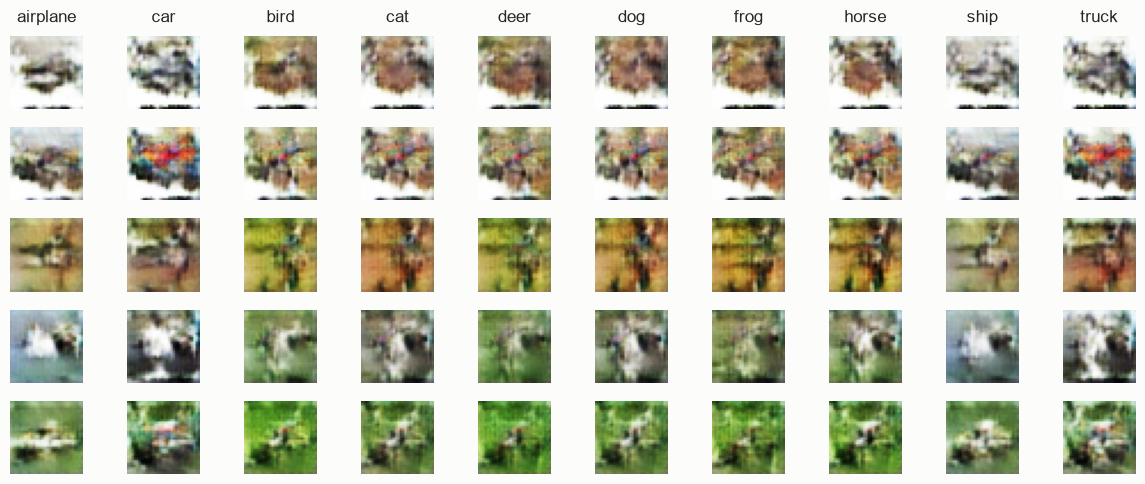

,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
experiment_1_ttur,NaN,0.691669,0.691733,0.694661,277.488647
experiment_2_labelsmoothing,NaN,0.974645,0.569433,0.518256,118.233215
experiment_3_spectralnorm,NaN,0.695215,0.695162,0.691113,204.611206
experiment_4_greyscale,NaN,0.742639,0.506967,0.679024,102.814789
experiment_5_engineered_conditioning,NaN,0.854043,0.573656,0.595989,119.930573
experiment_6_augmentation,NaN,1.065786,0.637636,0.468831,117.394493
experiment_7_acgan,NaN,0.895540,1.653923,0.561815,120.611053
experiment_8_deeper_architecture,NaN,0.863213,0.568792,0.643779,142.071945
experiment_9_alternating_downsample_and_upsample_layers,NaN,1.072897,0.617562,0.485366,157.717896


In [99]:
# Generate five samples per class, calculate FID, and add the experiment metrics to the results dataframe.
generate_class_images(G, validation_n_samples, 50)

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = 1000
samples_seen = 0

G.eval()
with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        labels = sample["label"][:remaining].to(device, non_blocking=True)
        noise = torch.randn(len(real_images), noise_dim, device=device)
        fake_images = G(noise, labels)

        fid.update(((real_images + 1) / 2).clamp(0, 1), real=True)
        fid.update(((fake_images + 1) / 2).clamp(0, 1), real=False)
        samples_seen += len(real_images)

fid_score = fid.compute().item()

experiment_10_results = {
    "quality_score": np.nan,
    "final_val_g_loss": g_loss_track["val"][-1],
    "final_val_real_d_loss": real_d_loss_track["val"][-1],
    "final_val_fake_d_loss": fake_d_loss_track["val"][-1],
    "fid_score": fid_score,
}
results = add_row_to_df(results, experiment_10_results, "experiment_10_residual_connections")
results

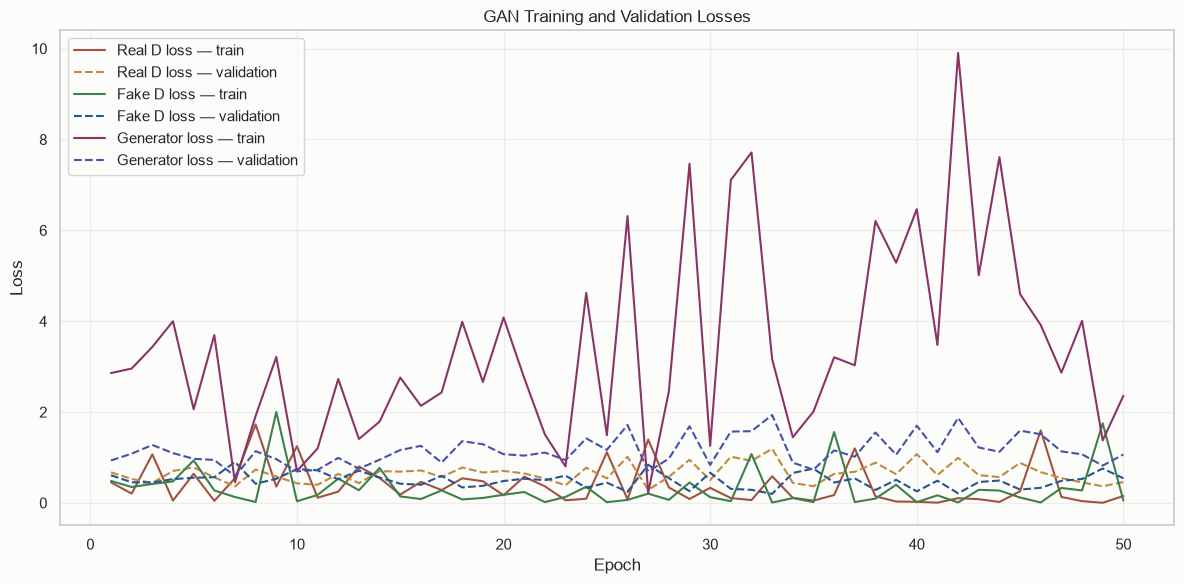

In [100]:
# Plot losses.
plot_combined_gan_losses(real_d_loss_track,fake_d_loss_track,g_loss_track)

### Notes

Residual refinement produced an FID of `141.707`, approximately `16.73%` worse than the baseline and only slightly better than the deeper architecture in Experiment 8. The final validation losses were approximately `1.065` for the generator, `0.458` for real discriminator inputs, and `0.540` for fake inputs. Generator training loss repeatedly spiked and reached almost `10`, so the residual paths did not stabilize adversarial optimization at the chosen learning rates. The sample grid showed some label-dependent color changes but continued to reuse similar structures across classes, giving no evidence that these residual blocks improved class fidelity.

## 13. Final Model

The final PyTorch model combines the compatible non-grayscale settings that individually beat the baseline FID: one-sided label smoothing, engineered RGB conditioning, and soft augmentation. AC-GAN is not combined because its image-only auxiliary discriminator conflicts with the discriminator-side conditioning used by the engineered features, while grayscale is a separate comparison rather than an RGB quality lever. The trained generator parameters are saved as a PyTorch state dictionary in `best_gan.pt`.

### 13.1 Select Best Settings

In [101]:
baseline_fid = results.loc["baseline", "fid_score"]
eligible_results = results.loc[
    (results["fid_score"] < baseline_fid)
    & (results.index != "experiment_4_greyscale")
].sort_values("fid_score")

# Best settings selected: Experiment 2 label smoothing, Experiment 5 engineered RGB conditioning, and Experiment 6 soft augmentation.
# AC-GAN also scored below baseline, but its image-only discriminator conflicts with Experiment 5's discriminator-side conditioning, so it is not combined here.
selected_settings = [
    "experiment_2_labelsmoothing",
    "experiment_5_engineered_conditioning",
    "experiment_6_augmentation",
]
selected_results = eligible_results.loc[selected_settings]
selected_results[["fid_score"]]

,fid_score
experiment_2_labelsmoothing,118.233215
experiment_5_engineered_conditioning,119.930573
experiment_6_augmentation,117.394493


### 13.2 Train the Final Model

In [102]:
# Build the Experiment 5 conditioned GAN, then reuse its training loop with
# Experiment 6 augmentation and Experiment 2 one-sided label smoothing.
G = generator(noise_dim)
D = discriminator()

G.proj = nn.Linear(noise_dim + 13, 128 * 4 * 4)
D.conv1 = nn.Conv2d(16, 32, 3, 2, 1)
D.register_forward_pre_hook(prepare_rgb_conditioning)

G = G.to(device)
D = D.to(device)
g_lr = 0.0002
d_lr = 0.0002
g_optim = torch.optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.9))
d_optim = torch.optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.9))
epochs = 50

fixed_noise_progression_grid = {}

D_x_track = {'train':[], 'val': []}
D_Gz_track = {'train':[], 'val': []}
real_d_loss_track = {'train':[], 'val': []}
fake_d_loss_track = {'train':[], 'val': []}
g_loss_track = {'train':[], 'val': []}

for e in range(epochs):
    D.train()
    G.train()
    print(f'\n\nEpoch {e}\n')
    for idx, sample in enumerate(rgb_train_loader):
   
        img = augmentation_pipeline(sample['img'].to(device, non_blocking=True))
        label = sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_smooth = torch.full((batch_size,), 0.9).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,noise_dim)).to(device)
        generated_img = G(noise, label)
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_smooth) # predict D(x) = 0.9

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        # repredicting so that this uses the updated discriminator for a fairer comparison
        with torch.no_grad():
            real_d_pred = D(img, label)
        
        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()
    print_template(D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    track_metrics('train', D_x, D_Gz, real_d_loss, fake_d_loss, g_loss)
    # validation
    D.eval()
    G.eval()
    for idx, v_sample in enumerate(rgb_val_loader):
        
        img = v_sample['img'].to(device, non_blocking=True)
        label = v_sample['label'].to(device, non_blocking=True)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        with torch.no_grad():
            v_generated_img = G(val_noise, label)

            v_real_pred = D(img, label) 
                        
            v_fake_pred = D(v_generated_img, label)

            v_real_d_loss = criterion(v_real_pred, target_ones)
            v_fake_d_loss = criterion(v_fake_pred, target_zeros)
            v_g_loss = criterion(v_fake_pred, target_ones)

            v_D_x = v_real_pred.mean()
            v_D_Gz = v_fake_pred.mean()
    track_metrics('val', v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    print('== Validation ==')
    print_template(v_D_x, v_D_Gz, v_real_d_loss, v_fake_d_loss, v_g_loss)
    # if (e+1)%5 == 0:
    #     generate_rgb_conditioned_class_images(G, validation_n_samples, e)



Epoch 0

D(x) = 0.4437
D(G(z)) = 0.3214
D Loss (real): 0.869 | D Loss (fake): 0.549
Generator Loss: 1.227
== Validation ==
D(x) = 0.4536
D(G(z)) = 0.3742
D Loss (real): 0.818 | D Loss (fake): 0.480
Generator Loss: 1.017


Epoch 1

D(x) = 0.4715
D(G(z)) = 0.3166
D Loss (real): 0.718 | D Loss (fake): 0.513
Generator Loss: 1.226
== Validation ==
D(x) = 0.4910
D(G(z)) = 0.3847
D Loss (real): 0.740 | D Loss (fake): 0.498
Generator Loss: 0.990


Epoch 2

D(x) = 0.5539
D(G(z)) = 0.2530
D Loss (real): 0.563 | D Loss (fake): 0.445
Generator Loss: 1.574
== Validation ==
D(x) = 0.5109
D(G(z)) = 0.2072
D Loss (real): 0.727 | D Loss (fake): 0.236
Generator Loss: 1.633


Epoch 3

D(x) = 0.5595
D(G(z)) = 0.2615
D Loss (real): 0.559 | D Loss (fake): 0.400
Generator Loss: 1.526
== Validation ==
D(x) = 0.5613
D(G(z)) = 0.2504
D Loss (real): 0.605 | D Loss (fake): 0.294
Generator Loss: 1.444


Epoch 4

D(x) = 0.6656
D(G(z)) = 0.2224
D Loss (real): 0.598 | D Loss (fake): 0.319
Generator Loss: 1.772
== V

In [103]:
# Save only the generator's weights. weights_only=True is used when loading a state dict, not by torch.save().
best_gan_path = Path("best_gan.pt")
torch.save(G.state_dict(), best_gan_path)
torch.load(best_gan_path, map_location="cpu", weights_only=True)
print(f"Saved generator weights to {best_gan_path}")

Saved generator weights to best_gan.pt


### 13.3 Evaluate the Final Model

In [105]:
# Generate 100 images per class with the final RGB-conditioned generator (1000 total).
from IPython.display import clear_output, display

images_per_class = 100
generated_images = []
generated_labels = []

G.eval()
with torch.no_grad():
    for class_idx in range(len(classes)):
        noise = torch.randn(images_per_class, noise_dim, device=device)
        one_hot_labels = torch.zeros(images_per_class, len(classes), device=device)
        one_hot_labels[:, class_idx] = 1
        rgb_features = class_rgb_vectors[class_idx].to(device).unsqueeze(0).expand(images_per_class, -1)
        conditioned_labels = torch.cat((one_hot_labels, rgb_features), dim=1)

        class_images = G(noise, conditioned_labels)
        generated_images.append(class_images.cpu())
        generated_labels.append(torch.full((images_per_class,), class_idx))

generated_images = torch.cat(generated_images)
generated_labels = torch.cat(generated_labels)

print("generated_images:", generated_images.shape)
print("generated_labels:", generated_labels.shape)

# Manually score five generated images per class (50 total), following the baseline eye-test loop.
n_score = 10
valid_scores = {"0": "n", "0.5": "m", "1": "c"}
final_quality_labels = {class_name: [] for class_name in classes}

for class_idx, class_name in enumerate(classes):
    class_images = generated_images[generated_labels == class_idx][:n_score]

    for image_idx, image in enumerate(class_images):
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(3, 3))
        image_01 = ((image + 1) / 2).clamp(0, 1)
        ax.imshow(image_01.permute(1, 2, 0).cpu().numpy())
        ax.set_title(f"Class: {class_name} | Image: {image_idx + 1}/{n_score}")
        ax.axis("off")
        plt.tight_layout()
        display(fig)

        while True:
            score_input = input(
                "Score (0 = nonsense, 0.5 = marginal, 1 = clear): "
            ).strip()

            if score_input in valid_scores:
                final_quality_labels[class_name].append(valid_scores[score_input])
                break

            print("Invalid score. Enter only 0, 0.5, or 1.")

        plt.close(fig)

clear_output(wait=True)
final_class_quality = {
    class_name: score_from_labels(labels)
    for class_name, labels in final_quality_labels.items()
}
final_quality_score = score_from_labels([
    label
    for labels in final_quality_labels.values()
    for label in labels
])

# Log directly into the existing results DataFrame; the FID cell fills the final column next.
result_columns = [
    "quality_score",
    "final_val_g_loss",
    "final_val_real_d_loss",
    "final_val_fake_d_loss",
    "fid_score",
]
results.loc["final_model", result_columns] = [
    final_quality_score,
    g_loss_track["val"][-1],
    real_d_loss_track["val"][-1],
    fake_d_loss_track["val"][-1],
    np.nan,
]

display(pd.Series(final_class_quality, name="quality_score").to_frame())
results.loc[["baseline", "final_model"]]

,quality_score
airplane,0.25
car,0.25
bird,0.20
cat,0.25
deer,0.15
dog,0.20
frog,0.10
horse,0.15
ship,0.30
truck,0.15


,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
final_model,0.20,0.979633,0.652153,0.503867,NaN


In [106]:
# Compute FID from the same 1000 generated images using the baseline evaluation code.
from torchmetrics.image.fid import FrechetInceptionDistance

fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
fid_n_samples = len(generated_images)
real_samples_seen = 0

with torch.no_grad():
    for sample in val_loader:
        remaining = fid_n_samples - real_samples_seen
        if remaining == 0:
            break

        real_images = sample["img"][:remaining].to(device, non_blocking=True)
        real_images = ((real_images + 1) / 2).clamp(0, 1)
        fid.update(real_images, real=True)
        real_samples_seen += len(real_images)

    for start in range(0, fid_n_samples, bs):
        fake_images = generated_images[start:start + bs].to(device)
        fake_images = ((fake_images + 1) / 2).clamp(0, 1)
        fid.update(fake_images, real=False)

fid_score = fid.compute().item()
results.loc["final_model", "fid_score"] = fid_score

print(f"FID score: {fid_score:.4f}")
results.loc[["baseline", "final_model"]]

FID score: 126.7596


,quality_score,final_val_g_loss,final_val_real_d_loss,final_val_fake_d_loss,fid_score
baseline,0.22,0.908666,0.546201,0.552436,121.398079
final_model,0.20,0.979633,0.652153,0.503867,126.759575


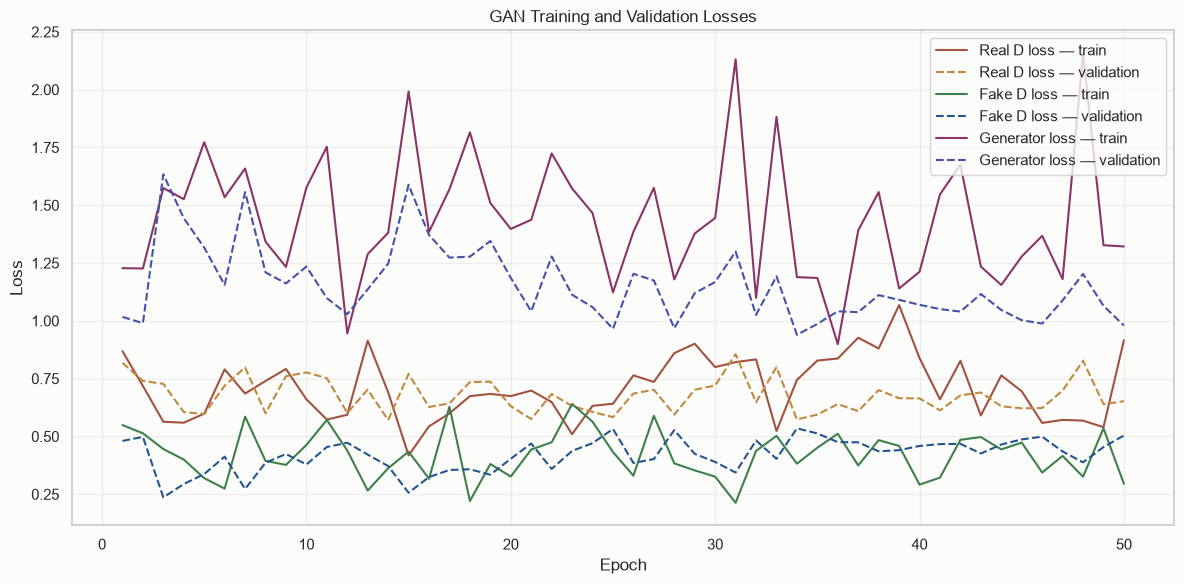

In [107]:
# Plot the final model's generator/discriminator loss curves.
plot_combined_gan_losses(real_d_loss_track, fake_d_loss_track, g_loss_track)

### Notes

The final model did not outperform the baseline. Its manual quality score was `0.200`, compared with the baseline's `0.220`, a decrease of `0.020` or approximately `9.09%`; ship was the strongest scored class at `0.300`, while frog was weakest at `0.100`. This manual comparison is descriptive because the final model was scored on 50 images while the saved baseline score used 100. FID used a matched 1,000-image procedure and increased from `121.398` to `126.760`, making it approximately `4.42%` worse. The validation generator, real-discriminator, and fake-discriminator losses ended at approximately `0.980`, `0.652`, and `0.504`, with continued oscillation in the curves, so the individually useful settings did not combine additively.

## 14. Ablation Summary

The ablation table collects the existing `results` DataFrame into one view, reporting the available manual quality scores, separate generator and discriminator validation losses, and the baseline/final FID values without recomputing any experiment.

In [111]:
# Build the ablation table from the existing results DataFrame.
ablation_table = results.copy()
# Keep FID in this summary only for the baseline and final model, as requested.
ablation_table["fid_score"] = ablation_table["fid_score"].where(
    ablation_table.index.isin(["baseline", "final_model"])
)
ablation_table = ablation_table.rename(columns={
    "final_val_g_loss": "g_loss",
    "final_val_fake_d_loss": "fake_d_loss",
    "final_val_real_d_loss": "real_d_loss",
})
ablation_table = ablation_table[[
    "quality_score",
    "g_loss",
    "fake_d_loss",
    "real_d_loss",
    "fid_score",
]]
ablation_table

,quality_score,g_loss,fake_d_loss,real_d_loss,fid_score
baseline,0.22,0.908666,0.552436,0.546201,121.398079
experiment_1_ttur,NaN,0.691669,0.694661,0.691733,NaN
experiment_2_labelsmoothing,NaN,0.974645,0.518256,0.569433,NaN
experiment_3_spectralnorm,NaN,0.695215,0.691113,0.695162,NaN
experiment_4_greyscale,NaN,0.742639,0.679024,0.506967,NaN
experiment_5_engineered_conditioning,NaN,0.854043,0.595989,0.573656,NaN
experiment_6_augmentation,NaN,1.065786,0.468831,0.637636,NaN
experiment_7_acgan,NaN,0.895540,0.561815,1.653923,NaN
experiment_8_deeper_architecture,NaN,0.863213,0.643779,0.568792,NaN
experiment_9_alternating_downsample_and_upsample_layers,NaN,1.072897,0.485366,0.617562,NaN


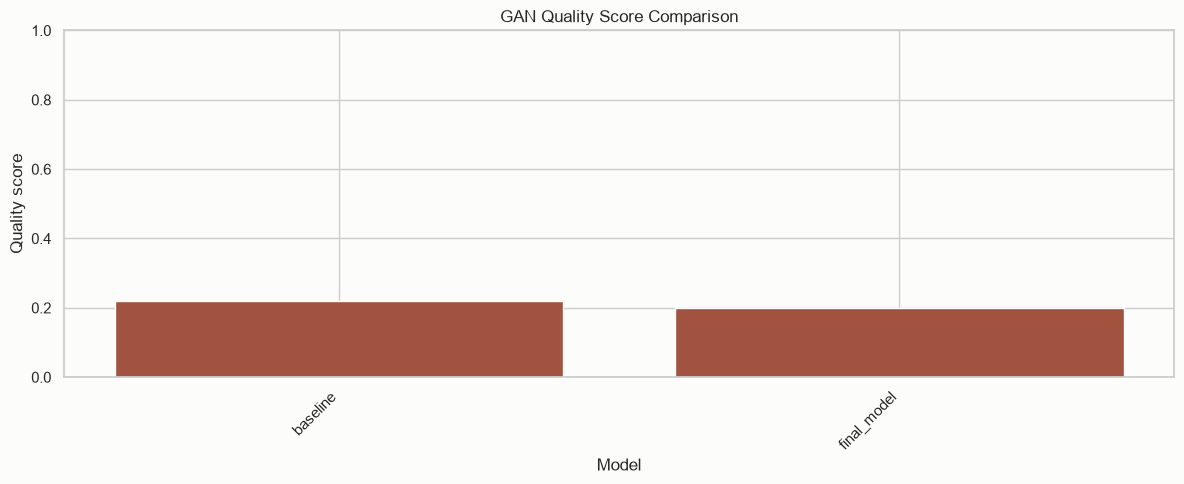

In [110]:
# Bar chart comparing every available (non-missing) quality score.
quality_scores = ablation_table["quality_score"].dropna()

plt.figure(figsize=(12, 5))
plt.bar(quality_scores.index, quality_scores.values, color=PALETTE[0])
plt.title("GAN Quality Score Comparison")
plt.xlabel("Model")
plt.ylabel("Quality score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 14. Conclusion

Among the individual RGB experiments, label smoothing, engineered conditioning, soft augmentation, and AC-GAN each reduced FID, with augmentation producing the best eligible score of `117.394`; TTUR, spectral normalization, the deeper models, alternating convolution types, and residual refinement all performed worse than the `121.398` baseline. Grayscale achieved `102.815` but was kept separate from the RGB final model. Combining the compatible winners did not yield an additive benefit: the final quality score decreased from `0.220` to `0.200` and FID increased to `126.760`. The PyTorch generator weights are saved as `best_gan.pt` alongside `baseline_g.pt` for the subsequent comparison in `vae_gan_comparison.ipynb`.